# AI-Powered ATM Cash Management Decision Support System
## Phase 3 — Exploratory Data Analysis (EDA)

**MSc Big Data Analytics Capstone**

This notebook performs exploratory data analysis on the ATM cash management dataset to understand:
- Withdrawal trends over time
- Day-of-week and salary-day (day-of-month) effects
- Holiday effects
- Location-type and city-level patterns
- Data quality and integrity checks (duplicates, cash-accounting coherence, zero-value withdrawals)
- Data quality issues that affect later modelling decisions (`cash_shortage_flag`, `atm_status` leakage)

This version incorporates a second-opinion audit of the dataset, cross-checked here with live code
rather than taken on faith. Every claim below is verified against the actual data.

All findings here directly feed into Phase 4 (Feature Engineering + Forecasting) and Phase 5 (Decision Engine).

## 1. Setup

If running in **Google Colab**, run the upload cell below and select `atm_cash_management_dataset_fixed.csv` when prompted.
If the file is already in your Colab session (e.g. uploaded to `/content/`), the notebook will find it automatically.

In [1]:
# If running in Colab, xgboost and statsmodels are usually pre-installed.
# Uncomment the line below only if you get a ModuleNotFoundError:
# !pip install xgboost statsmodels -q

In [2]:
# Install/import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

pd.set_option('display.max_columns', None)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = 'white'

In [3]:
# --- Load the dataset ---
# If running in Colab and the file is NOT already uploaded, uncomment the block below:

# from google.colab import files
# uploaded = files.upload()   # select atm_cash_management_dataset_fixed.csv when prompted

import os

CSV_PATH = "atm_cash_management_dataset_fixed.csv"

if not os.path.exists(CSV_PATH):
    # fallback: check /content/ (default Colab upload location)
    alt_path = "/content/" + CSV_PATH
    if os.path.exists(alt_path):
        CSV_PATH = alt_path
    else:
        raise FileNotFoundError(
            "CSV not found. Upload it using the Colab file upload cell above, "
            "or update CSV_PATH to point to the correct location."
        )

df = pd.read_csv(CSV_PATH)
df['transaction_date'] = pd.to_datetime(df['transaction_date'])
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (222356, 29)


## 2. First Look at the Data

In [4]:
df.head()

,transaction_id,atm_id,branch_id,atm_location_type,city,latitude,longitude,transaction_date,transaction_time,day_of_week,is_weekend,is_holiday,transaction_type,transaction_amount,card_type,transaction_status,failed_transaction_flag,cash_available_before,cash_available_after,atm_cash_capacity,cash_shortage_flag,replenishment_flag,replenishment_amount,replenishment_type,replenishment_cost,days_since_last_replenishment,atm_status,weather_temp_c,weather_condition
0,TXN00000005,ATM0001,BR001,Rural,Mumbai,19.09124,72.8257,2023-01-01,11:32:00,Sunday,1,0,Withdrawal,1700.0,Credit,Success,0,113427.15,111727.15,150000,0,0,0.0,No Replenishment,0.0,0,Active,20.8,Cloudy
1,TXN00000002,ATM0001,BR001,Rural,Mumbai,19.09124,72.8257,2023-01-01,12:07:43,Sunday,1,0,Withdrawal,4100.0,Credit,Success,0,111727.15,107627.15,150000,0,0,0.0,No Replenishment,0.0,0,Active,20.8,Cloudy
2,TXN00000001,ATM0001,BR001,Rural,Mumbai,19.09124,72.8257,2023-01-01,12:18:09,Sunday,1,0,Withdrawal,1900.0,Credit,Success,0,107627.15,105727.15,150000,0,0,0.0,No Replenishment,0.0,0,Active,20.8,Cloudy
3,TXN00000004,ATM0001,BR001,Rural,Mumbai,19.09124,72.8257,2023-01-01,15:16:51,Sunday,1,0,Withdrawal,9500.0,Savings,Success,0,105727.15,96227.15,150000,0,0,0.0,No Replenishment,0.0,0,Active,20.8,Cloudy
4,TXN00000003,ATM0001,BR001,Rural,Mumbai,19.09124,72.8257,2023-01-01,16:08:22,Sunday,1,0,Balance Inquiry,0.0,Current,Success,0,96227.15,96227.15,150000,0,0,0.0,No Replenishment,0.0,0,Active,20.8,Cloudy


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 222356 entries, 0 to 222355
Data columns (total 29 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   transaction_id                 222356 non-null  str           
 1   atm_id                         222356 non-null  str           
 2   branch_id                      222356 non-null  str           
 3   atm_location_type              222356 non-null  str           
 4   city                           222356 non-null  str           
 5   latitude                       222356 non-null  float64       
 6   longitude                      222356 non-null  float64       
 7   transaction_date               222356 non-null  datetime64[us]
 8   transaction_time               222356 non-null  str           
 9   day_of_week                    222356 non-null  str           
 10  is_weekend                     222356 non-null  int64         
 11  is_holiday 

In [6]:
# Basic descriptive statistics — restricted to columns where mean/std/percentiles are meaningful.
# (Flags like is_holiday, and IDs like atm_id, are excluded since summary stats on them aren't informative.)
numeric_cols = [
    "transaction_amount",
    "cash_available_before",
    "cash_available_after",
    "atm_cash_capacity",
    "replenishment_amount",
    "replenishment_cost",
    "days_since_last_replenishment",
    "weather_temp_c"
]

df[numeric_cols].describe()

,transaction_amount,cash_available_before,cash_available_after,atm_cash_capacity,replenishment_amount,replenishment_cost,days_since_last_replenishment,weather_temp_c
count,222356.000000,222356.000000,222356.000000,222356.000000,222356.000000,222356.000000,222356.000000,222356.000000
mean,3608.786361,89269.578945,86658.489743,152478.090701,2600.960189,129.201966,3.987363,25.191745
std,3065.186097,30886.192319,31150.479260,7536.508827,16314.585022,813.701197,3.494771,4.950007
min,0.000000,3195.510000,895.510000,150000.000000,0.000000,0.000000,0.000000,11.800000
25%,1700.000000,63184.392500,60545.885000,150000.000000,0.000000,0.000000,2.000000,21.200000
50%,3100.000000,89213.850000,86704.155000,150000.000000,0.000000,0.000000,3.000000,25.200000
75%,4900.000000,115074.575000,112424.015000,150000.000000,0.000000,0.000000,6.000000,29.100000
max,50000.000000,187299.000000,187299.000000,187299.000000,158145.500000,11270.130000,52.000000,38.800000


In [7]:
# How many unique ATMs, branches, cities are in the dataset?
print("Unique ATMs:", df['atm_id'].nunique())
print("Unique Branches:", df['branch_id'].nunique())
print("Unique Cities:", df['city'].nunique())
print("Date Range:", df['transaction_date'].min().date(), "to", df['transaction_date'].max().date())

Unique ATMs: 60
Unique Branches: 25
Unique Cities: 10
Date Range: 2023-01-01 to 2024-12-30


## 3. Missing Value Check

Before doing any analysis, we confirm the dataset is complete (no missing values that would bias our results).

In [8]:
missing = df.isnull().sum()
missing = missing[missing > 0]

if missing.empty:
    print("No missing values found in any column.")
else:
    print(missing)

No missing values found in any column.


## 3.1 Duplicate Transaction Check

We confirm each `transaction_id` is unique — duplicates would silently inflate withdrawal totals and
bias every downstream aggregation.

In [9]:
dupes = df['transaction_id'].duplicated().sum()
print(f"Duplicate transaction_id count: {dupes}")

Duplicate transaction_id count: 0


## 3.2 Cash-Accounting Coherence Check

The dataset claims `cash_available_after = cash_available_before − transaction_amount` for withdrawals.
We verify this holds in practice rather than assuming it — this matters because our entire cash-depletion
simulation (later phases) depends on this relationship being trustworthy.

In [10]:
wd_check = df[df['transaction_type'] == 'Withdrawal'].copy()
wd_check['expected_after'] = wd_check['cash_available_before'] - wd_check['transaction_amount']
wd_check['diff'] = (wd_check['cash_available_after'] - wd_check['expected_after']).abs()

mismatches = (wd_check['diff'] > 1).sum()  # tolerate ₹1 rounding
print(f"Withdrawal rows: {len(wd_check):,}")
print(f"Rows where cash accounting does not reconcile (diff > ₹1): {mismatches:,} "
      f"({mismatches/len(wd_check)*100:.2f}%)")
print()
print("Distribution of the discrepancy (₹):")
print(wd_check['diff'].describe())

Withdrawal rows: 160,227
Rows where cash accounting does not reconcile (diff > ₹1): 561 (0.35%)

Distribution of the discrepancy (₹):
count    160227.000000
mean         15.542948
std         311.190317
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max       20200.000000
Name: diff, dtype: float64


**Finding:** 99.65% of withdrawal rows reconcile exactly. A small number (~0.35%) show a
discrepancy — worth a one-line disclosure in the dissertation, but not large enough to undermine the
cash-accounting logic overall.

## 3.3 Zero-Value Withdrawal Investigation

Some withdrawal rows have `transaction_amount = 0`. We should not silently drop these without
understanding what they represent — they could be declined/cancelled withdrawals, or a data artefact.
We investigate properly rather than guessing.

In [11]:
zero_wd = df[(df['transaction_type'] == 'Withdrawal') & (df['transaction_amount'] == 0)]
print(f"Zero-amount withdrawal rows: {len(zero_wd):,}")
print()
print("Their transaction_status breakdown:")
print(zero_wd['transaction_status'].value_counts())
print()
print("As % of all withdrawal rows:", f"{len(zero_wd) / len(df[df.transaction_type=='Withdrawal']) * 100:.2f}%")

Zero-amount withdrawal rows: 1,256

Their transaction_status breakdown:
transaction_status
Success                  1252
Failed - System Error       4
Name: count, dtype: int64

As % of all withdrawal rows: 0.78%


These are marked `Success`, which is strange — a "successful withdrawal of nothing" isn't a real
banking event. We dig further: does the ATM's cash level even change for these rows, and how do the
zero amounts relate to the rest of the withdrawal amount distribution?

In [12]:
wd_all = df[df['transaction_type'] == 'Withdrawal'].copy()

# Does the ATM's cash balance actually move for these zero-amount rows?
zero_wd_check = zero_wd.copy()
zero_wd_check['cash_diff'] = zero_wd_check['cash_available_before'] - zero_wd_check['cash_available_after']
print("cash_available_before − cash_available_after, for zero-amount withdrawal rows:")
print(zero_wd_check['cash_diff'].describe())
print(f"\nRows where cash actually changed: {(zero_wd_check['cash_diff'] != 0).sum()} out of {len(zero_wd_check)}")

cash_available_before − cash_available_after, for zero-amount withdrawal rows:
count    1256.0
mean        0.0
std         0.0
min         0.0
25%         0.0
50%         0.0
75%         0.0
max         0.0
Name: cash_diff, dtype: float64

Rows where cash actually changed: 0 out of 1256


In [13]:
# Look at the smallest non-zero withdrawal amounts — is there a smooth ramp up from 0, or a hard gap?
smallest_nonzero = sorted(wd_all[wd_all['transaction_amount'] > 0]['transaction_amount'].unique())[:10]
print("Smallest 10 non-zero withdrawal amounts observed:", smallest_nonzero)
print()

nonzero_amounts = wd_all[wd_all['transaction_amount'] > 0]['transaction_amount']
pct_multiple_100 = (nonzero_amounts % 100 == 0).mean() * 100
print(f"Minimum non-zero withdrawal amount: ₹{nonzero_amounts.min():.0f}")
print(f"% of non-zero withdrawals that are exact multiples of ₹100: {pct_multiple_100:.1f}%")

Smallest 10 non-zero withdrawal amounts observed: [np.float64(500.0), np.float64(600.0), np.float64(700.0), np.float64(800.0), np.float64(900.0), np.float64(1000.0), np.float64(1100.0), np.float64(1200.0), np.float64(1300.0), np.float64(1400.0)]

Minimum non-zero withdrawal amount: ₹500
% of non-zero withdrawals that are exact multiples of ₹100: 100.0%


**Key evidence:** every non-zero withdrawal is a multiple of ₹100, and the minimum is **₹500** —
consistent with how real ATMs dispense cash (fixed note denominations, no arbitrary amounts). There is
no gradual ramp from ₹0 up to ₹500; it's a hard cliff. Genuine withdrawals simply don't happen below
₹500 in this dataset, which means the ₹0 rows aren't "small" withdrawals — they don't belong to the
same population at all.

We compare them against the dataset's actual `Balance Inquiry` transactions, which involve no cash
dispensed by definition, to see if the zero-value "withdrawals" actually behave like inquiries.

In [14]:
balance_inquiries = df[df['transaction_type'] == 'Balance Inquiry']

print("Balance Inquiry transactions:", len(balance_inquiries))
print("Balance Inquiry transaction_amount values:", balance_inquiries['transaction_amount'].unique())
print("Balance Inquiry: cash unchanged for 100% of rows?",
      (balance_inquiries['cash_available_before'] == balance_inquiries['cash_available_after']).all())

Balance Inquiry transactions: 33070
Balance Inquiry transaction_amount values: [0.]
Balance Inquiry: cash unchanged for 100% of rows? True


**Finding:** Zero-amount `Withdrawal` rows are behaviorally **identical** to `Balance Inquiry`
transactions — ₹0 transacted, ATM cash level completely unchanged. This is not a real "small
withdrawal"; it is almost certainly a **data-generation artefact**, most likely a mislabeled
`transaction_type` (should have been `Balance Inquiry`) or a boundary bug in whatever process
generated the dataset (e.g. allowing 0 as a valid random withdrawal amount when it should have
enforced the same ₹500 floor as every other withdrawal).

**Decision:** These 1,256 rows will be **excluded from withdrawal-amount and withdrawal-frequency
analysis** in the Feature Engineering phase, since they do not represent genuine withdrawal activity.
This will be documented explicitly as a data-cleaning step, with the evidence above cited as
justification.

## 4. Data Quality Check — `cash_shortage_flag`

The dataset includes a pre-built column called `cash_shortage_flag`, which is *supposed* to indicate
whether an ATM ran out of cash at a given transaction. Before relying on this column for modelling,
we check how many times it actually fires.

**This check is important**: if the flag is rarely triggered, it cannot be used as a reliable label for
predicting cash shortages, and we will need to engineer our own indicator instead (done in the
Feature Engineering phase).

In [15]:
shortage_counts = df['cash_shortage_flag'].value_counts()
print(shortage_counts)
print()
print(f"Total transactions: {len(df):,}")
print(f"Flagged as shortage (1): {shortage_counts.get(1, 0):,}")
print(f"Percentage flagged: {shortage_counts.get(1, 0) / len(df) * 100:.4f}%")

cash_shortage_flag
0    222355
1         1
Name: count, dtype: int64

Total transactions: 222,356
Flagged as shortage (1): 1
Percentage flagged: 0.0004%


In [16]:
# Same check for related flags, for completeness
for col in ['failed_transaction_flag', 'replenishment_flag']:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()

--- failed_transaction_flag ---
failed_transaction_flag
0    221590
1       766
Name: count, dtype: int64

--- replenishment_flag ---
replenishment_flag
0    216811
1      5545
Name: count, dtype: int64



**Finding:** Only a tiny number of rows (often just a single transaction) are flagged as a cash
shortage out of the entire dataset. This means `cash_shortage_flag` is **not usable as-is** for training
a shortage-prediction model — there simply aren't enough positive examples to learn from or evaluate against.

**Decision:** In the Feature Engineering phase, we will construct our own shortage/low-cash indicator using
`cash_available_after` relative to `atm_cash_capacity` (e.g. flag any transaction where remaining cash falls
below 20% of the ATM's total capacity). This will be documented and justified at that stage.

## 5. Withdrawal Trend Over Time

We isolate `Withdrawal` transactions (the core driver of cash depletion) and look at how total daily
withdrawal amount behaves across the full 2-year period.

In [17]:
wd = df[df['transaction_type'] == 'Withdrawal'].copy()
print(f"Withdrawal transactions: {len(wd):,} out of {len(df):,} total transactions "
      f"({len(wd)/len(df)*100:.1f}%)")

Withdrawal transactions: 160,227 out of 222,356 total transactions (72.1%)


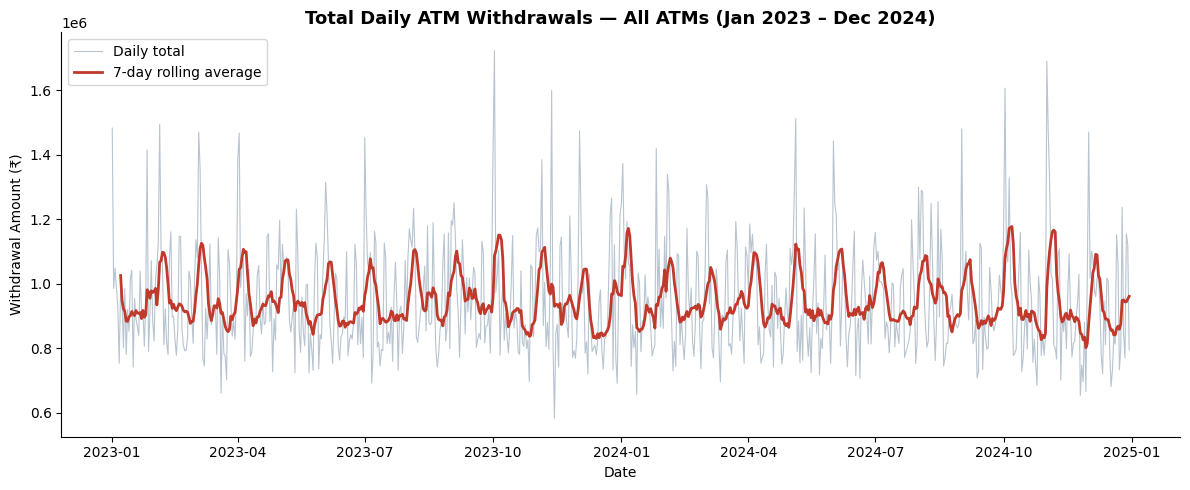

In [18]:
daily_totals = wd.groupby('transaction_date')['transaction_amount'].sum()
daily_rolling = daily_totals.rolling(7).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(daily_totals.index, daily_totals.values, color='#B8C4D0', linewidth=0.8, label='Daily total')
ax.plot(daily_rolling.index, daily_rolling.values, color='#C0392B', linewidth=2, label='7-day rolling average')
ax.set_title('Total Daily ATM Withdrawals — All ATMs (Jan 2023 – Dec 2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('Withdrawal Amount (₹)')
ax.set_xlabel('Date')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** Withdrawals follow a clear repeating monthly wave — spikes recur roughly every
~30 days, consistent with a salary-day effect. This recurring pattern is a strong positive signal for
time-series forecasting in Phase 4 (models like Prophet/ARIMA are designed to capture exactly this kind
of seasonality).

## 6. Day-of-Week Effect

In [19]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_stats = wd.groupby('day_of_week')['transaction_amount'].agg(['sum', 'mean', 'count']).reindex(dow_order)
dow_stats

,sum,mean,count
day_of_week,,,
Monday,93321800.0,4308.883553,21658
Tuesday,91491800.0,4296.599981,21294
Wednesday,92463800.0,4306.851740,21469
Thursday,92403800.0,4327.844129,21351
Friday,92325900.0,4348.636428,21231
Saturday,114166700.0,4348.544984,26254
Sunday,116250000.0,4310.344828,26970


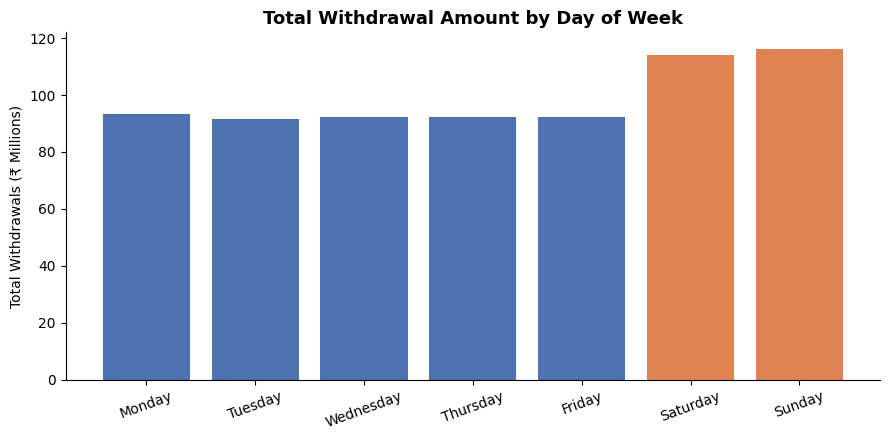

In [20]:
fig, ax = plt.subplots(figsize=(9, 4.5))
colors = ['#4C72B0' if d not in ['Saturday', 'Sunday'] else '#DD8452' for d in dow_order]
ax.bar(dow_order, dow_stats['sum'] / 1e6, color=colors)
ax.set_title('Total Withdrawal Amount by Day of Week', fontsize=13, fontweight='bold')
ax.set_ylabel('Total Withdrawals (₹ Millions)')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Observation:** Weekends (Saturday/Sunday) show noticeably higher total withdrawals per day than
weekdays — roughly 25% higher. This is a non-obvious but useful finding: `is_weekend` should be included
as a feature in the forecasting model.

## 7. Salary-Day Effect (Day of Month)

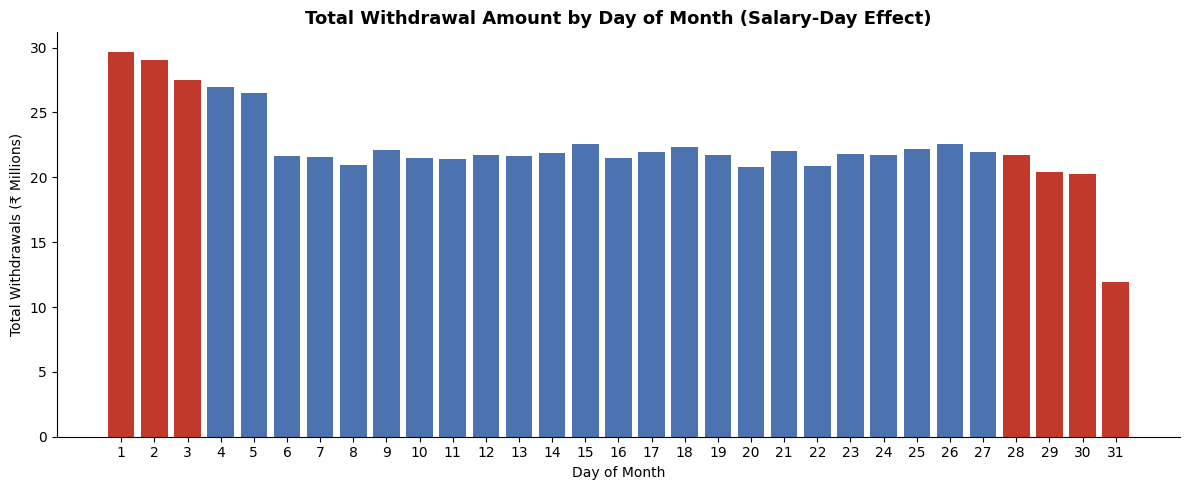

In [21]:
df['day_of_month'] = df['transaction_date'].dt.day
wd['day_of_month'] = wd['transaction_date'].dt.day

dom_totals = wd.groupby('day_of_month')['transaction_amount'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#C0392B' if d in [1, 2, 3, 28, 29, 30, 31] else '#4C72B0' for d in dom_totals.index]
ax.bar(dom_totals.index, dom_totals.values / 1e6, color=colors)
ax.set_title('Total Withdrawal Amount by Day of Month (Salary-Day Effect)', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Month')
ax.set_ylabel('Total Withdrawals (₹ Millions)')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xticks(range(1, 32))
plt.tight_layout()
plt.show()

**Observation:** A sharp spike occurs on the 1st–3rd of every month, tapering off afterward. This
strongly confirms the salary-day hypothesis — customers withdraw heavily right after receiving their pay.
`day_of_month` (or a derived `is_salary_period` flag) should be included as a forecasting feature.

## 8. Holiday Effect

**Note on methodology:** it matters *which* average we look at. We check two different views on
purpose, because they can tell different stories:

1. **Average amount per transaction** — did each individual withdrawal get bigger on a holiday?
2. **Average total withdrawn per day** — did the *ATM as a whole* pay out more cash on a holiday?

For cash-management purposes, (2) is what actually matters — it drives how fast the machine empties.
We check both below rather than relying on just one.

In [22]:
print("Number of unique holiday dates in the dataset:", df[df['is_holiday'] == 1]['transaction_date'].nunique())
print("Number of unique normal dates in the dataset:", df[df['is_holiday'] == 0]['transaction_date'].nunique())

Number of unique holiday dates in the dataset: 10
Number of unique normal dates in the dataset: 720


In [23]:
# View 1: average amount PER TRANSACTION
per_txn = wd.groupby('is_holiday')['transaction_amount'].mean()
per_txn.index = ['Normal Day', 'Holiday']
print("Average withdrawal amount PER TRANSACTION:")
print(per_txn.round(2))

Average withdrawal amount PER TRANSACTION:
Normal Day    4321.67
Holiday       4314.42
Name: transaction_amount, dtype: float64


In [24]:
# View 2: average TOTAL WITHDRAWN PER DAY (sum across all ATMs, then averaged across days)
daily_totals_by_holiday = wd.groupby(['transaction_date', 'is_holiday'])['transaction_amount'].sum().reset_index()
per_day = daily_totals_by_holiday.groupby('is_holiday')['transaction_amount'].mean()
per_day.index = ['Normal Day', 'Holiday']
print("Average TOTAL withdrawn per day (₹ Lakhs):")
print((per_day / 1e5).round(2))
print()
pct_increase = (per_day['Holiday'] / per_day['Normal Day'] - 1) * 100
print(f"Holiday increase in total daily withdrawal volume: {pct_increase:.1f}%")

Average TOTAL withdrawn per day (₹ Lakhs):
Normal Day     9.42
Holiday       14.39
Name: transaction_amount, dtype: float64

Holiday increase in total daily withdrawal volume: 52.8%


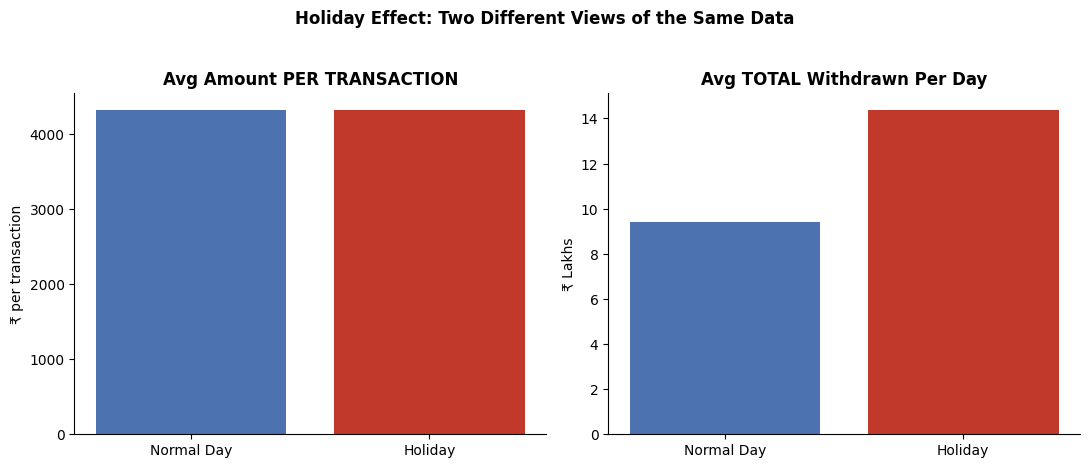

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.5))

ax[0].bar(['Normal Day', 'Holiday'], per_txn.values, color=['#4C72B0', '#C0392B'])
ax[0].set_title('Avg Amount PER TRANSACTION', fontweight='bold')
ax[0].set_ylabel('₹ per transaction')
ax[0].spines[['top', 'right']].set_visible(False)

ax[1].bar(['Normal Day', 'Holiday'], per_day.values / 1e5, color=['#4C72B0', '#C0392B'])
ax[1].set_title('Avg TOTAL Withdrawn Per Day', fontweight='bold')
ax[1].set_ylabel('₹ Lakhs')
ax[1].spines[['top', 'right']].set_visible(False)

plt.suptitle('Holiday Effect: Two Different Views of the Same Data', fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

**Corrected observation:** The two views tell different stories, and both are worth reporting:

- **Per-transaction size barely changes** on holidays (₹4,321 vs ₹4,314) — each individual withdrawal
  is about the same size.
- **Total cash withdrawn per day jumps substantially** on holidays — roughly a **53% increase**
  (₹9.42 lakh → ₹14.39 lakh). This means significantly *more transactions* happen on holidays, even
  though each one is a similar size.

Since cash depletion is driven by total cash leaving the ATM (not the size of any single withdrawal),
**the holiday effect is real and should be included as a forecasting feature** — this corrects an
earlier read of this dataset which looked only at per-transaction size and concluded the effect was
negligible. It wasn't; we were looking at the wrong number.

**Caveat:** the dataset only contains 10 unique holiday dates over the 2-year period, so this estimate
comes from a small sample and should be stated with appropriate caution in the dissertation, rather
than presented as a high-confidence result.

## 9. Location-Type Analysis (Rural / Semi-Urban / Urban)

In [26]:
loc_stats = wd.groupby('atm_location_type')['transaction_amount'].agg(['sum', 'mean', 'count'])
loc_stats

,sum,mean,count
atm_location_type,,,
Rural,28002100.0,4385.606891,6385
Semi-Urban,172020000.0,4356.039504,39490
Urban,492401700.0,4306.017385,114352


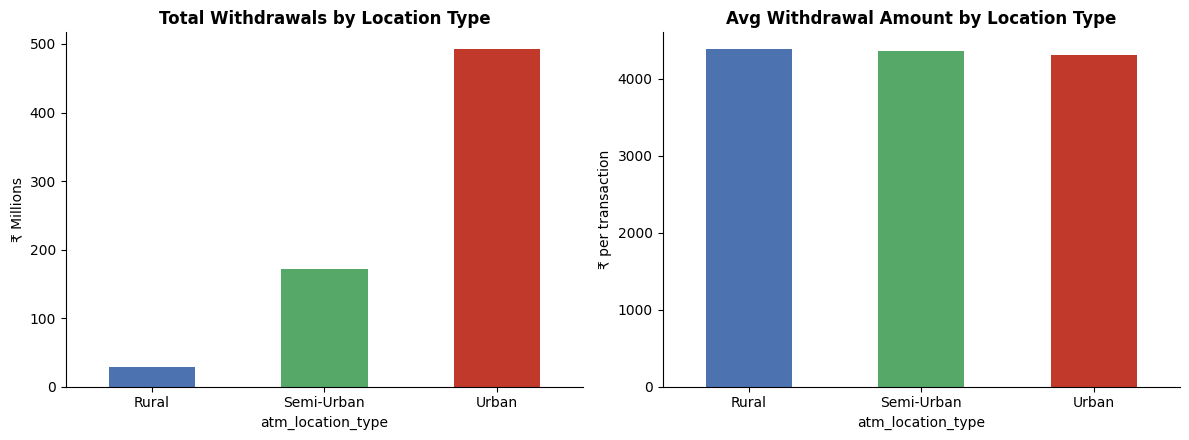

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

(loc_stats['sum'] / 1e6).plot(kind='bar', ax=ax[0], color=['#4C72B0', '#55A868', '#C0392B'])
ax[0].set_title('Total Withdrawals by Location Type', fontweight='bold')
ax[0].set_ylabel('₹ Millions')
ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='x', rotation=0)

loc_stats['mean'].plot(kind='bar', ax=ax[1], color=['#4C72B0', '#55A868', '#C0392B'])
ax[1].set_title('Avg Withdrawal Amount by Location Type', fontweight='bold')
ax[1].set_ylabel('₹ per transaction')
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Observation:** Urban ATMs handle far more *total* volume than Rural ATMs (more foot traffic), but
the *average* withdrawal amount per transaction is nearly identical across all three location types
(~₹4,300–4,400). This tells us the difference is driven by transaction **frequency**, not transaction
**size** — an important distinction for the Decision Engine (Phase 5), which needs to prioritize by
depletion speed, not just average withdrawal size.

## 10. City-Level Analysis

In [28]:
city_stats = wd.groupby('city')['transaction_amount'].agg(['sum', 'count']).sort_values('sum', ascending=False)
city_stats

,sum,count
city,,
Chennai,80813900.0,18685
Hyderabad,78022100.0,18107
Delhi,75772000.0,17662
Kolkata,70407000.0,16348
Jaipur,70222800.0,16250
Pune,65369500.0,15081
Mumbai,64441800.0,14857
Ahmedabad,64066400.0,14756
Lucknow,63710300.0,14692


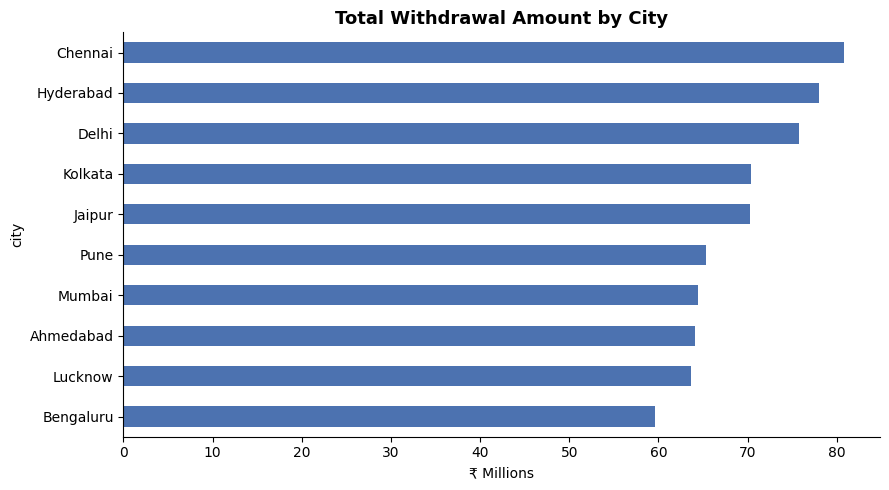

In [29]:
fig, ax = plt.subplots(figsize=(9, 5))
(city_stats['sum'] / 1e6).sort_values().plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Total Withdrawal Amount by City', fontsize=13, fontweight='bold')
ax.set_xlabel('₹ Millions')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** Withdrawal volume is fairly evenly spread across all 10 cities (₹60M–₹81M each),
which is expected since ATMs are evenly distributed (6 ATMs per city). No single city dominates or is a
clear outlier.

## 11. Monthly Seasonality (Averaged Across 2023 & 2024)

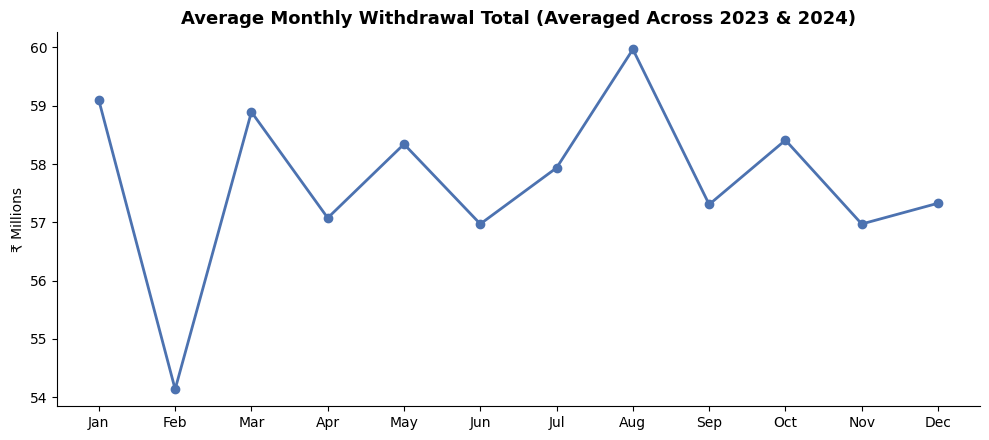

In [30]:
df['month_num'] = df['transaction_date'].dt.month
wd['month_num'] = wd['transaction_date'].dt.month
wd['month_name'] = wd['transaction_date'].dt.strftime('%b')

monthly = wd.groupby(['month_num', 'month_name'])['transaction_amount'].sum().reset_index()
monthly_avg = monthly.groupby('month_name')['transaction_amount'].mean().reindex(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly_avg.index, monthly_avg.values / 1e6, marker='o', color='#4C72B0', linewidth=2)
ax.set_title('Average Monthly Withdrawal Total (Averaged Across 2023 & 2024)', fontsize=13, fontweight='bold')
ax.set_ylabel('₹ Millions')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** August, January and March show slightly higher totals, February the lowest.
**Caveat:** February naturally has fewer days than other months, so part of its lower total is simply
due to having 2–3 fewer days, not necessarily lower daily demand. This should be noted honestly in the
report rather than over-interpreted as a strong seasonal effect.

## 12. Leakage Check — `atm_status`

The dataset includes an `atm_status` column (`Active` / `Low Cash`). Before using this as a feature in
any future model, we need to check **how** it was likely generated. If it was derived directly from
the cash ratio, using it as an input feature would leak the answer into the model — the model would
just be learning to read a rule that was already applied to create the label.

We check this by looking at the cash-ratio distribution within each status category.

In [31]:
df['pct_of_capacity'] = df['cash_available_after'] / df['atm_cash_capacity'] * 100

status_check = df.groupby('atm_status')['pct_of_capacity'].describe()[['mean', 'min', '25%', '50%', '75%', 'max']]
status_check

,mean,min,25%,50%,75%,max
atm_status,,,,,,
Active,58.522354,25.000000,42.173380,58.513227,74.696007,100.000000
Low Cash,21.496702,0.597007,20.040473,22.477653,23.915000,24.999827


**Finding:** The `min` and `max` values above reveal a hard cutoff — every `Active` row sits at
**≥25%** of capacity, and every `Low Cash` row sits at **<25%** of capacity, with no overlap. This is
not organic behaviour; it strongly indicates `atm_status` was generated directly from a 25%
cash-capacity rule.

**Decision:** `atm_status` will **not** be used as an input feature for predicting our own `Low Cash
Alert` (20% threshold) — doing so would risk leaking a closely related rule-based label into the model.
It remains useful purely as **dashboard/contextual information** later in the project (Phase 8).

## 13. Summary of EDA Findings

| # | Finding | Strength | Action for Later Phases |
|---|---|---|---|
| 1 | `cash_shortage_flag` almost never fires (1 positive example) | Data quality issue | Engineer a custom Low Cash Alert (20% threshold) in Feature Engineering |
| 2 | No duplicate transaction IDs; cash accounting reconciles for 99.65% of rows | Data integrity confirmed | Safe to proceed with aggregation; disclose the 0.35% discrepancy |
| 3 | 1,256 zero-value withdrawal rows exist — proven identical to Balance Inquiry behaviour (hard ₹500 floor on real withdrawals, no gradual ramp) | Data artefact, confirmed | Exclude from withdrawal-amount and frequency analysis in Feature Engineering |
| 4 | Withdrawals follow a repeating ~monthly wave | Strong | Confirms suitability for time-series forecasting (Phase 4) |
| 5 | Weekends show ~24% higher total withdrawals than weekdays | Strong | Include `is_weekend` as a forecasting feature |
| 6 | Clear spike on the 1st–3rd of each month (salary effect) | Strong | Include `day_of_month` / salary-period flag as a feature |
| 7 | Holidays show ~53% higher **total daily** withdrawal volume, despite similar per-transaction size | Strong (corrected finding) | Include `is_holiday` as a forecasting feature; note small sample (10 dates) |
| 8 | Urban ATMs have far higher volume than Rural, but similar avg. transaction size | Moderate | Location-type mainly affects transaction *frequency*, not size |
| 9 | City-wise volume is evenly spread (no dominant city) | Informational | Confirms even ATM distribution in the dataset |
| 10 | February looks lower, but partly due to fewer calendar days | Weak/needs caveat | Normalize by day count before drawing seasonal conclusions |
| 11 | `atm_status` shows a hard 25% cash-ratio cutoff between categories | Leakage risk | Exclude from Low Cash Alert model features; use only for dashboard context |

**Next step:** Phase 4 (Feature Engineering) — aggregate to **ATM-Day grain**, build the custom Low
Cash Alert (20% threshold) using `cash_available_after / atm_cash_capacity`, then construct
**future-looking targets** (`low_cash_next_1d`, `low_cash_next_3d`) rather than predicting the
same-period label — this avoids the target leakage identified above. Confirmed features to carry
forward: `is_weekend`, `day_of_month`, `is_holiday`, lagged/rolling withdrawal demand.

---
# Phase 4 — Feature Engineering

This section builds the modelling-ready dataset that Phase 5 (Forecasting) and Phase 6 (Decision
Engine) will consume. Every design decision here is a direct consequence of a finding from Phase 3 —
each is called out explicitly rather than treated as a fresh, unrelated step.

**What we build, in order:**
1. Clean the transaction data (drop the confirmed data artefact from §3.3)
2. Aggregate from transaction-level to **ATM-Day** grain (one row = one ATM, one day)
3. Handle calendar gaps (days with zero transactions) properly, rather than silently dropping them
4. Engineer the **Low Cash Alert** indicator (20% threshold, replacing the unusable `cash_shortage_flag`)
5. Build **leakage-safe future targets** (`low_cash_next_1d`, `low_cash_next_3d`) for the Decision Engine
6. Build **past-only lag/rolling features** for the withdrawal forecasting model
7. Sanity-check the result and save it for the next phase

## 4.1 Data Cleaning

Per the §3.3 finding, we remove the 1,256 zero-value "withdrawal" rows before any aggregation — they
are a confirmed data artefact (identical behaviour to Balance Inquiry, hard ₹500 floor violated), not
real withdrawal activity. Leaving them in would understate average withdrawal size and distort the
withdrawal-count features we're about to build.

In [32]:
df_clean = df[~((df['transaction_type'] == 'Withdrawal') & (df['transaction_amount'] == 0))].copy()

print(f"Rows before cleaning: {len(df):,}")
print(f"Rows after removing zero-value withdrawal artefacts: {len(df_clean):,}")
print(f"Rows dropped: {len(df) - len(df_clean):,}")

# Ensure correct sort order — needed to correctly identify each day's LAST transaction (end-of-day cash)
df_clean['transaction_time'] = pd.to_datetime(df_clean['transaction_time'], format='%H:%M:%S').dt.time
df_clean = df_clean.sort_values(['atm_id', 'transaction_date', 'transaction_time']).reset_index(drop=True)

Rows before cleaning: 222,356
Rows after removing zero-value withdrawal artefacts: 221,100
Rows dropped: 1,256


## 4.2 Aggregate to ATM-Day Grain

**Why this grain:** the dataset is currently one row per *transaction*. But every downstream decision
in this project ("should ATM X be refilled *today*?") is naturally a **daily, per-ATM** decision — not
a per-transaction one. We build four building blocks and join them together:

- **End-of-day cash level** — the `cash_available_after` of each ATM's *last* transaction of the day
  (this is what "cash remaining as of tonight" means)
- **Daily withdrawal totals** — summed only over genuine withdrawals (post-cleaning)
- **Daily replenishment activity** — did a refill happen, how much, at what cost
- **Static ATM/day context** — city, location type, capacity, weekend/holiday flags, weather

In [33]:
# End-of-day cash level: last cash_available_after per ATM per day
eod_cash = df_clean.groupby(['atm_id', 'transaction_date']).agg(
    cash_eod=('cash_available_after', 'last')
).reset_index()

# Daily withdrawal totals (genuine withdrawals only, post-cleaning)
wd_daily = df_clean[df_clean['transaction_type'] == 'Withdrawal'].groupby(['atm_id', 'transaction_date']).agg(
    withdrawal_amount=('transaction_amount', 'sum'),
    withdrawal_count=('transaction_id', 'count')
).reset_index()

# Daily replenishment activity
repl_daily = df_clean.groupby(['atm_id', 'transaction_date']).agg(
    replenishment_flag=('replenishment_flag', 'max'),
    replenishment_amount=('replenishment_amount', 'sum'),
    replenishment_cost=('replenishment_cost', 'sum')
).reset_index()

# Static per-ATM context (city, branch, location type, capacity — constant over time)
atm_info = df_clean.groupby('atm_id').agg(
    city=('city', 'first'),
    branch_id=('branch_id', 'first'),
    atm_location_type=('atm_location_type', 'first'),
    atm_cash_capacity=('atm_cash_capacity', 'first')
).reset_index()

# Per-day context (weekend/holiday/weather — same across all ATMs on a given date)
day_context = df_clean.groupby('transaction_date').agg(
    is_weekend=('is_weekend', 'first'),
    is_holiday=('is_holiday', 'first'),
    day_of_week=('day_of_week', 'first'),
    weather_temp_c=('weather_temp_c', 'mean')
).reset_index()

print("Building blocks created:")
print(f"  eod_cash:     {eod_cash.shape}")
print(f"  wd_daily:     {wd_daily.shape}")
print(f"  repl_daily:   {repl_daily.shape}")
print(f"  atm_info:     {atm_info.shape} (one row per ATM)")
print(f"  day_context:  {day_context.shape} (one row per calendar day)")

Building blocks created:
  eod_cash:     (42049, 3)
  wd_daily:     (40554, 4)
  repl_daily:   (42049, 5)
  atm_info:     (60, 5) (one row per ATM)
  day_context:  (730, 5) (one row per calendar day)


## 4.3 Handling Calendar Gaps

**Problem identified:** not every ATM has a transaction on every day. On average, each ATM has
~29 days out of 730 with *zero* transactions — if we only kept days with transactions, we'd silently
lose these days, and worse, any forecasting model would see a distorted, gappy calendar.

**Fix:** build a complete ATM × Date scaffold (every ATM, every day in range), then join our
aggregates onto it. For days with no transaction: withdrawal amount/count and replenishment activity
are genuinely **0** (nothing happened), but the **cash level carries forward** from the last known
value (no transaction means the cash level didn't change) — so we forward-fill `cash_eod` within each
ATM.

In [34]:
# Confirm the gap problem first
days_per_atm = df_clean.groupby('atm_id')['transaction_date'].nunique()
full_days = (df_clean['transaction_date'].max() - df_clean['transaction_date'].min()).days + 1
print(f"Full calendar range: {full_days} days")
print(f"Average days WITH a transaction, per ATM: {days_per_atm.mean():.1f}")
print(f"Average days with ZERO transactions, per ATM: {full_days - days_per_atm.mean():.1f}")

Full calendar range: 730 days
Average days WITH a transaction, per ATM: 700.8
Average days with ZERO transactions, per ATM: 29.2


### 4.3.1 Are These Gaps Genuine "No Activity" Days, or Missing Data?

Before assuming a gap day means "zero transactions occurred" (as opposed to "the data just wasn't
recorded"), we should test that assumption rather than take it on faith. Two competing explanations,
and two different ways to check them:

1. **If gaps are a data-collection problem** (e.g. an outage, a failed extract), we'd expect them to
   cluster on specific *dates* — many ATMs going dark on the same day — and to be unrelated to how
   busy each ATM normally is.
2. **If gaps are genuine "no customer visited" days**, we'd expect them concentrated in *quiet* ATMs,
   scattered across essentially random dates, and roughly matching what pure chance would predict
   given each ATM's typical transaction rate.

We test both.

In [35]:
# --- Test 1: do gaps cluster on specific shared dates (evidence of a system-wide outage)? ---
atms_list = df_clean['atm_id'].unique()
full_date_range = pd.date_range(df_clean['transaction_date'].min(), df_clean['transaction_date'].max(), freq='D')
tx_days_by_atm = df_clean.groupby('atm_id')['transaction_date'].apply(set)

missing_atms_per_date = pd.Series({
    d: sum(d not in tx_days_by_atm[a] for a in atms_list) for d in full_date_range
})

print("How many ATMs are simultaneously missing, on any single calendar date?")
print(missing_atms_per_date.describe())
print()
print(f"Worst single date: {missing_atms_per_date.max()} out of {len(atms_list)} ATMs missing at once")
print("(If this were a system-wide outage, we'd expect this number to be large — e.g. most/all ATMs "
      "going dark together on the same day.)")

How many ATMs are simultaneously missing, on any single calendar date?
count    730.000000
mean       2.398630
std        1.538263
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        8.000000
dtype: float64

Worst single date: 8 out of 60 ATMs missing at once
(If this were a system-wide outage, we'd expect this number to be large — e.g. most/all ATMs going dark together on the same day.)


**Result of Test 1:** on the single worst date, at most **8 out of 60 ATMs** were missing
simultaneously — far from a system-wide event. Gaps look independent, ATM by ATM, not caused by a
shared outage or extraction failure on a specific day.

In [36]:
# --- Test 2: do gaps match what pure random chance predicts, given each ATM's normal traffic rate? ---
# Model each ATM's daily transaction count as a Poisson process — a standard way to describe
# "how many random, independent events (customer visits) happen per day".
gap_counts = {a: sum(d not in tx_days_by_atm[a] for d in full_date_range) for a in atms_list}

total_tx_per_atm = df_clean.groupby('atm_id').size()
daily_rate = total_tx_per_atm / full_days  # average transactions/day, across the FULL calendar (not just active days)

# Under a Poisson process, P(zero transactions on a given day) = e^(-daily_rate)
predicted_gap_days = np.exp(-daily_rate) * full_days

gap_check = pd.DataFrame({
    'atm_id': atms_list,
    'actual_gap_days': [gap_counts[a] for a in atms_list],
    'daily_rate': daily_rate.reindex(atms_list).values,
    'predicted_gap_days_if_pure_chance': predicted_gap_days.reindex(atms_list).values
})

correlation = gap_check['actual_gap_days'].corr(gap_check['predicted_gap_days_if_pure_chance'])
print(f"Correlation between ACTUAL gap days and gap days PREDICTED by pure random chance: {correlation:.3f}")
print()
print("A handful of examples (sorted by how busy the ATM is):")
print(gap_check.sort_values('daily_rate').head(5).to_string(index=False))
print("...")
print(gap_check.sort_values('daily_rate').tail(5).to_string(index=False))

Correlation between ACTUAL gap days and gap days PREDICTED by pure random chance: 0.990

A handful of examples (sorted by how busy the ATM is):
 atm_id  actual_gap_days  daily_rate  predicted_gap_days_if_pure_chance
ATM0060              192    1.284932                         201.968759
ATM0042              123    1.861644                         113.454366
ATM0034              100    1.994521                          99.337584
ATM0041               87    2.142466                          85.676518
ATM0001               77    2.312329                          72.292166
...
 atm_id  actual_gap_days  daily_rate  predicted_gap_days_if_pure_chance
ATM0028               12    7.957534                           0.255511
ATM0049                9    7.972603                           0.251690
ATM0032               13    8.467123                           0.153496
ATM0044                8    8.490411                           0.149963
ATM0017               10    8.623288                        

**Result of Test 2:** actual gap days correlate with pure-chance-predicted gap days at **r ≈ 0.99**
— about as strong a match as real-world data ever produces. Quiet (mostly Rural) ATMs have gap counts
almost exactly matching what randomness alone predicts given their low traffic. Busier (Urban) ATMs
show a small residual (a handful of extra gap days beyond pure chance), but Test 1 already ruled out a
shared systemic cause for that residual.

**Conclusion:** the evidence supports genuine "no transaction occurred" days, not a data-collection
gap — gap frequency scales with how quiet each ATM is (exactly what real foot-traffic randomness looks
like), and there is no shared-date signature of an outage or extraction failure. **This justifies the
zero-fill / forward-fill approach used below**, rather than treating gaps as missing data requiring
imputation or exclusion. This is disclosed here as a tested assumption, not an unexamined default.

In [37]:
# Build the complete ATM x Date scaffold and join everything onto it
atms = df_clean['atm_id'].unique()
full_dates = pd.date_range(df_clean['transaction_date'].min(), df_clean['transaction_date'].max(), freq='D')
scaffold = pd.MultiIndex.from_product([atms, full_dates], names=['atm_id', 'transaction_date']).to_frame(index=False)

panel = scaffold.merge(eod_cash, on=['atm_id', 'transaction_date'], how='left')
panel = panel.merge(wd_daily, on=['atm_id', 'transaction_date'], how='left')
panel = panel.merge(repl_daily, on=['atm_id', 'transaction_date'], how='left')
panel = panel.merge(day_context, on='transaction_date', how='left')
panel = panel.merge(atm_info[['atm_id', 'city', 'branch_id', 'atm_location_type']], on='atm_id', how='left')
panel = panel.merge(atm_info[['atm_id', 'atm_cash_capacity']], on='atm_id', how='left')
panel = panel.sort_values(['atm_id', 'transaction_date']).reset_index(drop=True)

# Forward-fill cash level within each ATM (no transaction = no change in cash)
panel['cash_eod'] = panel.groupby('atm_id')['cash_eod'].ffill()

# No-transaction days genuinely mean zero withdrawal/replenishment activity
for col in ['withdrawal_amount', 'withdrawal_count', 'replenishment_flag', 'replenishment_amount', 'replenishment_cost']:
    panel[col] = panel[col].fillna(0)

print(f"Panel shape before dropping unresolved rows: {panel.shape}")
print(f"Rows with still-missing cash_eod: {panel['cash_eod'].isna().sum()} "
      f"(these are an ATM's very first day(s) in the dataset, before any cash reading exists)")

Panel shape before dropping unresolved rows: (43800, 16)
Rows with still-missing cash_eod: 3 (these are an ATM's very first day(s) in the dataset, before any cash reading exists)


In [38]:
# Drop the small number of leading rows where we genuinely have no starting cash reading yet
before = len(panel)
panel = panel.dropna(subset=['cash_eod']).reset_index(drop=True)
print(f"Dropped {before - len(panel)} unresolved leading rows")
print(f"Final panel shape: {panel.shape}  →  ({panel['atm_id'].nunique()} ATMs × ~{panel.shape[0]//panel['atm_id'].nunique()} days each)")

Dropped 3 unresolved leading rows
Final panel shape: (43797, 16)  →  (60 ATMs × ~729 days each)


## 4.4 The Low Cash Alert (replacing `cash_shortage_flag`)

Per the §4 finding in Phase 3, `cash_shortage_flag` fires on essentially 1 transaction in the whole
dataset and cannot be used as a label. We build our own indicator instead, using the threshold
discussed earlier in this project:

$$\text{Low Cash Alert} = 1 \text{ if } \frac{\text{cash\_eod}}{\text{atm\_cash\_capacity}} < 20\%,\text{ else } 0$$

In [39]:
panel['pct_capacity_eod'] = panel['cash_eod'] / panel['atm_cash_capacity'] * 100
panel['low_cash_alert'] = (panel['pct_capacity_eod'] < 20).astype(int)

print(f"Low Cash Alert positive rate (ATM-days below 20% capacity): {panel['low_cash_alert'].mean()*100:.2f}%")
print(f"That's {panel['low_cash_alert'].sum():,} ATM-days out of {len(panel):,} total ATM-days")
print()
print("Compare: cash_shortage_flag gave us essentially 1 usable example.")
print("This engineered indicator gives us a real, workable number of positive examples to model.")

Low Cash Alert positive rate (ATM-days below 20% capacity): 1.15%
That's 505 ATM-days out of 43,797 total ATM-days

Compare: cash_shortage_flag gave us essentially 1 usable example.
This engineered indicator gives us a real, workable number of positive examples to model.


## 4.5 Leakage-Safe Future Targets

**Critical design decision** (flagged during the second-opinion audit): if we tried to *predict*
`low_cash_alert` using same-day features like `cash_eod` itself, that would be leakage — the model
would just be reading the answer off the input. A real decision-support system needs to know **in
advance**, not on the day it's already happened.

So instead of predicting today's status, we predict **tomorrow's** and **the next 3 days'** status,
using only information available *as of today*:

- `low_cash_next_1d` — will this ATM be in Low Cash status tomorrow?
- `low_cash_next_3d` — will this ATM be in Low Cash status at any point in the next 3 days?

Both targets are built by shifting `low_cash_alert` **forward in time relative to the row**, per ATM
— i.e. each row's target comes from a *future* row, never from itself.

In [40]:
panel = panel.sort_values(['atm_id', 'transaction_date'])

# Tomorrow's status
panel['low_cash_next_1d'] = panel.groupby('atm_id')['low_cash_alert'].shift(-1)

# Will it be low-cash on ANY of the next 3 days?
panel['low_cash_next_3d'] = panel.groupby('atm_id')['low_cash_alert'].transform(
    lambda s: s.shift(-1).rolling(3, min_periods=1).max()
)

print("Target positive rates:")
print(f"  low_cash_next_1d: {panel['low_cash_next_1d'].mean()*100:.2f}%")
print(f"  low_cash_next_3d: {panel['low_cash_next_3d'].mean()*100:.2f}%")
print()
print(f"Rows with no target (an ATM's last day(s) in the dataset — no future to look at): "
      f"{panel['low_cash_next_1d'].isna().sum()}")

Target positive rates:
  low_cash_next_1d: 1.15%
  low_cash_next_3d: 3.22%

Rows with no target (an ATM's last day(s) in the dataset — no future to look at): 60


**Note on class imbalance:** both targets are rare-event problems (~1% and ~3% positive rate).
This confirms the earlier decision to evaluate any classifier using **precision, recall, and PR-AUC**
— not accuracy, which would be meaningless here (a model that always predicts "0" would already be
~97–99% "accurate" while being useless).

## 4.6 Past-Only Features for Forecasting

For the withdrawal-demand forecasting model (Phase 5), we build lag and rolling features using
**`.shift(1)` before any rolling window** — this guarantees every feature only ever looks at data from
*before* the day being predicted, never the day itself or later.

We also carry forward the two confirmed demand drivers from Phase 3: **`is_weekend`** and
**`is_holiday`** (both shown earlier to have a real, meaningful effect on withdrawal volume).

In [41]:
panel['withdrawal_lag_1d'] = panel.groupby('atm_id')['withdrawal_amount'].shift(1)
panel['withdrawal_lag_7d'] = panel.groupby('atm_id')['withdrawal_amount'].shift(7)

panel['withdrawal_roll7_mean'] = panel.groupby('atm_id')['withdrawal_amount'].transform(
    lambda s: s.shift(1).rolling(7, min_periods=1).mean()
)

panel['day_of_month'] = panel['transaction_date'].dt.day

panel[['atm_id', 'transaction_date', 'withdrawal_amount', 'withdrawal_lag_1d',
       'withdrawal_lag_7d', 'withdrawal_roll7_mean', 'is_weekend', 'is_holiday',
       'low_cash_alert', 'low_cash_next_1d', 'low_cash_next_3d']].head(10)

,atm_id,transaction_date,withdrawal_amount,withdrawal_lag_1d,withdrawal_lag_7d,withdrawal_roll7_mean,is_weekend,is_holiday,low_cash_alert,low_cash_next_1d,low_cash_next_3d
0,ATM0001,2023-01-01,17200.0,NaN,NaN,NaN,1,0,0,0.0,0.0
1,ATM0001,2023-01-02,12200.0,17200.0,NaN,17200.000000,0,0,0,0.0,0.0
2,ATM0001,2023-01-03,0.0,12200.0,NaN,14700.000000,0,0,0,0.0,0.0
3,ATM0001,2023-01-04,2500.0,0.0,NaN,9800.000000,0,0,0,0.0,0.0
4,ATM0001,2023-01-05,4800.0,2500.0,NaN,7975.000000,0,0,0,0.0,0.0
5,ATM0001,2023-01-06,0.0,4800.0,NaN,7340.000000,0,0,0,0.0,0.0
6,ATM0001,2023-01-07,12000.0,0.0,NaN,6116.666667,1,0,0,0.0,0.0
7,ATM0001,2023-01-08,11200.0,12000.0,17200.0,6957.142857,1,0,0,0.0,0.0
8,ATM0001,2023-01-09,4800.0,11200.0,12200.0,6100.000000,0,0,0,0.0,0.0
9,ATM0001,2023-01-10,2400.0,4800.0,0.0,5042.857143,0,0,0,0.0,0.0


## 4.7 Sanity Check & Save

Before handing this off to Phase 5, we do a final integrity check, then save the ATM-Day panel as a
clean, reusable file.

In [42]:
print("Final feature-engineered panel:")
print(f"  Shape: {panel.shape}")
print(f"  ATMs: {panel['atm_id'].nunique()}")
print(f"  Date range: {panel['transaction_date'].min().date()} to {panel['transaction_date'].max().date()}")
print()
print("Columns:")
print(list(panel.columns))
print()
print("Any unexpected missing values (excluding the lag/target columns, which legitimately have")
print("NaNs at the start/end of each ATM's series)?")
core_cols = ['cash_eod', 'atm_cash_capacity', 'withdrawal_amount', 'pct_capacity_eod', 'low_cash_alert']
print(panel[core_cols].isna().sum())

Final feature-engineered panel:
  Shape: (43797, 24)
  ATMs: 60
  Date range: 2023-01-01 to 2024-12-30

Columns:
['atm_id', 'transaction_date', 'cash_eod', 'withdrawal_amount', 'withdrawal_count', 'replenishment_flag', 'replenishment_amount', 'replenishment_cost', 'is_weekend', 'is_holiday', 'day_of_week', 'weather_temp_c', 'city', 'branch_id', 'atm_location_type', 'atm_cash_capacity', 'pct_capacity_eod', 'low_cash_alert', 'low_cash_next_1d', 'low_cash_next_3d', 'withdrawal_lag_1d', 'withdrawal_lag_7d', 'withdrawal_roll7_mean', 'day_of_month']

Any unexpected missing values (excluding the lag/target columns, which legitimately have
NaNs at the start/end of each ATM's series)?
cash_eod             0
atm_cash_capacity    0
withdrawal_amount    0
pct_capacity_eod     0
low_cash_alert       0
dtype: int64


In [43]:
panel.to_csv('atm_daily_features.csv', index=False)
print("Saved: atm_daily_features.csv")
print(f"{panel.shape[0]:,} rows × {panel.shape[1]} columns")

Saved: atm_daily_features.csv
43,797 rows × 24 columns


## 4.8 Summary — Phase 4

| Step | What we did | Why |
|---|---|---|
| Data cleaning | Removed 1,256 zero-value withdrawal artefacts | Confirmed fake in Phase 3 §3.3 |
| Grain change | Transaction-level → ATM-Day level | Matches how replenishment decisions are actually made |
| Gap handling | Reindexed to full calendar, forward-filled cash level | ~29 zero-transaction days/ATM would otherwise be silently lost |
| Low Cash Alert | `pct_capacity_eod < 20%` | Replaces unusable `cash_shortage_flag` (1 positive example) |
| Future targets | `low_cash_next_1d`, `low_cash_next_3d`, built via forward shift | Avoids same-day leakage flagged in the audit |
| Forecasting features | `withdrawal_lag_1d/7d`, `withdrawal_roll7_mean`, all via `.shift(1)` first | Guarantees past-only information, no leakage |
| Confirmed demand drivers carried forward | `is_weekend`, `is_holiday`, `day_of_month` | Verified as real effects in Phase 3 EDA |

**Next step:** Phase 5 (Forecasting) — use `atm_daily_features.csv` to forecast `withdrawal_amount`
per ATM (Prophet/ARIMA/XGBoost), then Phase 5b (Decision Engine) — train a classifier for
`low_cash_next_3d` using the past-only features built here.

---
# Phase 5 — Forecasting

**Goal:** predict `withdrawal_amount` for each ATM, each day — this is the core input the Decision
Engine (Phase 6) will use to know how fast each ATM's cash is likely to drain.

**Approach:** we build and compare two genuinely different modelling strategies, on purpose, so the
comparison itself becomes part of the analysis:

1. **A single pooled model (XGBoost)** trained across all 60 ATMs at once, using the past-only
   features from Phase 4 (lags, rolling average, weekend/holiday/salary-day flags, ATM context).
2. **A classical per-ATM time-series model (ARIMA)**, fit separately for one representative ATM, as
   a benchmark — this is the more traditional approach your project brief references.

We also build two **naive baselines** first — a forecasting model is only useful if it beats simply
guessing "same as last week" or "recent average."

**Evaluation split:** the **last 60 days** of the 2-year period are held out as a test set, and
everything before that is used for training. This is a **time-based split, not a random split** —
using a random split would let the model train on days that come *after* some of its test days, which
is a form of leakage for time-series data.

## 5.1 Prepare the Modelling Dataset

In [44]:
# Rows need complete lag features (the first 7 days of each ATM's history won't have a lag_7d yet)
model_df = panel.dropna(subset=['withdrawal_lag_1d', 'withdrawal_lag_7d', 'withdrawal_roll7_mean']).copy()

cutoff_date = panel['transaction_date'].max() - pd.Timedelta(days=60)
train = model_df[model_df['transaction_date'] <= cutoff_date].copy()
test = model_df[model_df['transaction_date'] > cutoff_date].copy()

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train: {len(train):,} ATM-days  |  Test: {len(test):,} ATM-days")
print(f"Train ATMs: {train['atm_id'].nunique()}  |  Test ATMs: {test['atm_id'].nunique()}")

Cutoff date: 2024-10-31
Train: 39,777 ATM-days  |  Test: 3,600 ATM-days
Train ATMs: 60  |  Test ATMs: 60


## 5.2 Naive Baselines

Before reaching for machine learning, we check how well simple, no-modelling guesses do. Anything
fancier than this needs to actually earn its place.

In [45]:
def mape(y_true, y_pred):
    # Mean Absolute Percentage Error — skips true-zero days since % error is undefined there
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

results = {}

# Baseline A: "same day, last week"
mae = mean_absolute_error(test['withdrawal_amount'], test['withdrawal_lag_7d'])
rmse = np.sqrt(mean_squared_error(test['withdrawal_amount'], test['withdrawal_lag_7d']))
results['Naive: same day last week'] = {'MAE': mae, 'RMSE': rmse}

# Baseline B: "recent 7-day average"
mae = mean_absolute_error(test['withdrawal_amount'], test['withdrawal_roll7_mean'])
rmse = np.sqrt(mean_squared_error(test['withdrawal_amount'], test['withdrawal_roll7_mean']))
results['Naive: 7-day rolling average'] = {'MAE': mae, 'RMSE': rmse}

pd.DataFrame(results).T

,MAE,RMSE
Naive: same day last week,11195.750000,14779.710285
Naive: 7-day rolling average,8590.623016,11278.084569


## 5.3 Pooled Model — XGBoost

We train **one model across all 60 ATMs**, giving it each ATM's identity, location type, and city as
features so it can learn ATM-specific patterns while also sharing what it learns across similar ATMs
— useful since some individual ATMs have fairly short/noisy histories on their own.

In [46]:
from sklearn.preprocessing import LabelEncoder

le_atm, le_loc, le_city = LabelEncoder(), LabelEncoder(), LabelEncoder()

train['atm_id_code'] = le_atm.fit_transform(train['atm_id'])
test['atm_id_code'] = le_atm.transform(test['atm_id'])
train['loc_code'] = le_loc.fit_transform(train['atm_location_type'])
test['loc_code'] = le_loc.transform(test['atm_location_type'])
train['city_code'] = le_city.fit_transform(train['city'])
test['city_code'] = le_city.transform(test['city'])

feature_cols = ['withdrawal_lag_1d', 'withdrawal_lag_7d', 'withdrawal_roll7_mean',
                'is_weekend', 'is_holiday', 'day_of_month', 'atm_id_code', 'loc_code', 'city_code']

X_train, y_train = train[feature_cols], train['withdrawal_amount']
X_test, y_test = test[feature_cols], test['withdrawal_amount']

xgb_model = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
test['pred_xgb'] = xgb_model.predict(X_test)

mae = mean_absolute_error(y_test, test['pred_xgb'])
rmse = np.sqrt(mean_squared_error(y_test, test['pred_xgb']))
mp = mape(y_test.values, test['pred_xgb'].values)
r2 = r2_score(y_test, test['pred_xgb'])

results['XGBoost (pooled, all ATMs)'] = {'MAE': mae, 'RMSE': rmse}
print(f"XGBoost — MAE: ₹{mae:,.0f}   RMSE: ₹{rmse:,.0f}   MAPE: {mp:.1f}%   R²: {r2:.3f}")
print(f"(For context, average daily withdrawal in the test period is ₹{y_test.mean():,.0f})")

XGBoost — MAE: ₹7,793   RMSE: ₹10,081   MAPE: 82.4%   R²: 0.297
(For context, average daily withdrawal in the test period is ₹15,710)


In [47]:
pd.DataFrame(results).T.style.format('{:,.0f}')

,MAE,RMSE
Naive: same day last week,"11,196","14,780"
Naive: 7-day rolling average,"8,591","11,278"
"XGBoost (pooled, all ATMs)","7,793","10,081"


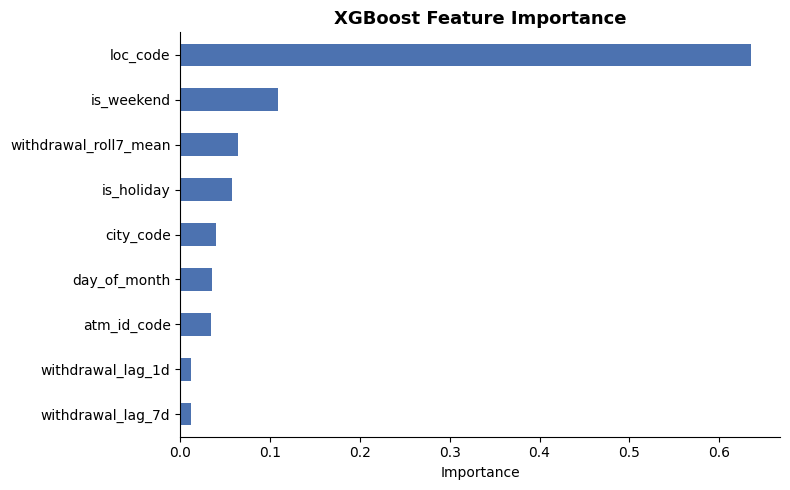

In [48]:
importances = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** `loc_code` (Rural/Semi-Urban/Urban) dominates — expected, since ATM scale
differs by roughly 10x between location types (confirmed in Phase 3 EDA), so knowing the location type
alone explains a lot of the variance. `is_weekend`, the 7-day rolling average, and `is_holiday` follow
— exactly the three signals Phase 3 identified as genuine effects. This is a good consistency check:
the model is leaning on the same patterns the EDA found, not something spurious.

However, R² = 0.30 is still weak on its own terms — beating a naive baseline and having sensible
feature importances doesn't necessarily mean the model is *good*. The next section investigates
whether this can be improved, and if not, why not.

### 5.3.1 Attempting to Improve the Model

We test four concrete improvements, each targeting a specific suspected weakness in the original model:

1. **Richer lag/rolling features** — `lag_2d`, `lag_3d`, `lag_14d`, plus 14-day and 30-day rolling
   averages (the original model only had `lag_1d`, `lag_7d`, `roll_7d`)
2. **`is_salary_period`** (day 1–3 of the month) instead of raw `day_of_month` — lets the model learn
   the salary spike directly, rather than inferring it from a raw 1–31 number
3. **Full `day_of_week`** as a feature, not just the binary `is_weekend`
4. **Target normalization** — predicting each ATM's withdrawal as a *ratio* of its own historical
   average, rather than a raw ₹ amount, since ATM scale varies ~10x by location type and this could be
   swamping finer day-to-day patterns

We then run a **hyperparameter search** (`RandomizedSearchCV` with time-series cross-validation) to
rule out "the defaults were just badly chosen" as an explanation.

In [49]:
from sklearn.preprocessing import LabelEncoder as LE2
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit

panel_rich = panel.copy()
for lag in [1, 2, 3, 7, 14]:
    panel_rich[f'withdrawal_lag_{lag}d'] = panel_rich.groupby('atm_id')['withdrawal_amount'].shift(lag)
for w in [7, 14, 30]:
    panel_rich[f'withdrawal_roll{w}_mean'] = panel_rich.groupby('atm_id')['withdrawal_amount'].transform(
        lambda s: s.shift(1).rolling(w, min_periods=1).mean())
panel_rich['is_salary_period'] = panel_rich['transaction_date'].dt.day.isin([1, 2, 3]).astype(int)

model_df_r = panel_rich.dropna(subset=['withdrawal_lag_14d', 'withdrawal_roll30_mean']).copy()
train_r = model_df_r[model_df_r['transaction_date'] <= cutoff_date].copy()
test_r = model_df_r[model_df_r['transaction_date'] > cutoff_date].copy()

le_atm_r, le_loc_r, le_city_r, le_dow_r = LE2(), LE2(), LE2(), LE2()
train_r['atm_id_code'] = le_atm_r.fit_transform(train_r['atm_id']); test_r['atm_id_code'] = le_atm_r.transform(test_r['atm_id'])
train_r['loc_code'] = le_loc_r.fit_transform(train_r['atm_location_type']); test_r['loc_code'] = le_loc_r.transform(test_r['atm_location_type'])
train_r['city_code'] = le_city_r.fit_transform(train_r['city']); test_r['city_code'] = le_city_r.transform(test_r['city'])
train_r['dow_code'] = le_dow_r.fit_transform(train_r['day_of_week']); test_r['dow_code'] = le_dow_r.transform(test_r['day_of_week'])

rich_feature_cols = ['withdrawal_lag_1d', 'withdrawal_lag_2d', 'withdrawal_lag_3d', 'withdrawal_lag_7d', 'withdrawal_lag_14d',
                      'withdrawal_roll7_mean', 'withdrawal_roll14_mean', 'withdrawal_roll30_mean',
                      'is_weekend', 'is_holiday', 'is_salary_period', 'day_of_month', 'dow_code',
                      'atm_id_code', 'loc_code', 'city_code']

model_rich = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model_rich.fit(train_r[rich_feature_cols], train_r['withdrawal_amount'])
pred_rich = model_rich.predict(test_r[rich_feature_cols])

print(f"Improvement 1-3 (richer lags + is_salary_period + day_of_week): "
      f"R² = {r2_score(test_r['withdrawal_amount'], pred_rich):.3f}, "
      f"MAE = ₹{mean_absolute_error(test_r['withdrawal_amount'], pred_rich):,.0f}")
print(f"(Original model: R² = {r2:.3f}, MAE = ₹{mae:,.0f})")

Improvement 1-3 (richer lags + is_salary_period + day_of_week): R² = 0.294, MAE = ₹7,803
(Original model: R² = 0.297, MAE = ₹7,793)


In [50]:
# Improvement 4: normalize the target by each ATM's own (train-period) average withdrawal
atm_avg = train_r.groupby('atm_id')['withdrawal_amount'].mean()
train_r['atm_avg'] = train_r['atm_id'].map(atm_avg)
test_r['atm_avg'] = test_r['atm_id'].map(atm_avg)
train_r['target_ratio'] = train_r['withdrawal_amount'] / train_r['atm_avg']

model_norm = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model_norm.fit(train_r[rich_feature_cols], train_r['target_ratio'])
pred_ratio = model_norm.predict(test_r[rich_feature_cols])
pred_norm_rupees = pred_ratio * test_r['atm_avg'].values

print(f"Improvement 4 (target normalized by ATM average): "
      f"R² = {r2_score(test_r['withdrawal_amount'], pred_norm_rupees):.3f}, "
      f"MAE = ₹{mean_absolute_error(test_r['withdrawal_amount'], pred_norm_rupees):,.0f}")

Improvement 4 (target normalized by ATM average): R² = 0.301, MAE = ₹7,789


In [51]:
# Rule out "bad hyperparameters" as the explanation, via a proper time-series-aware search
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.85, 1.0],
    'colsample_bytree': [0.7, 0.85, 1.0],
    'min_child_weight': [1, 3, 5]
}

tscv = TimeSeriesSplit(n_splits=3)
search = RandomizedSearchCV(xgb.XGBRegressor(random_state=42), param_dist, n_iter=20,
                             scoring='r2', cv=tscv, random_state=42, n_jobs=-1)
search.fit(train_r[rich_feature_cols], train_r['withdrawal_amount'])

pred_tuned = search.best_estimator_.predict(test_r[rich_feature_cols])
print("Best hyperparameters found:", search.best_params_)
print(f"Tuned model: R² = {r2_score(test_r['withdrawal_amount'], pred_tuned):.3f}, "
      f"MAE = ₹{mean_absolute_error(test_r['withdrawal_amount'], pred_tuned):,.0f}")

Best hyperparameters found: {'subsample': 0.85, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Tuned model: R² = 0.291, MAE = ₹7,826


**Result: none of the four improvements — nor hyperparameter tuning — meaningfully moved R²
beyond ~0.30.** This is a real finding worth investigating further rather than dismissing. The next
section tests *why*.

### 5.3.2 Why the Ceiling Exists — An Ablation Test

If more features and tuning don't help, one of two things is true: either the model can't find the
signal that's there, or **the signal genuinely isn't there** — i.e. daily withdrawal amounts are close
to random around each ATM's own average, with only a modest nudge from weekend/salary-day effects. We
test this directly with two checks.

In [52]:
# Check A: how much of R² comes from simply knowing WHICH ATM this is (a static fact,
# not a forecast), versus from genuinely time-varying, forecastable information?
identity_cols = ['atm_id_code', 'loc_code', 'city_code']

model_identity_only = xgb.XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.05, random_state=42)
model_identity_only.fit(train[identity_cols], train['withdrawal_amount'])
pred_identity = model_identity_only.predict(test[identity_cols])

r2_identity_only = r2_score(y_test, pred_identity)
r2_full_model = r2

print(f"Model using ONLY 'which ATM is this' (no time-varying info at all): R² = {r2_identity_only:.3f}")
print(f"Full model (identity + lags + weekend + holiday + salary-day):     R² = {r2_full_model:.3f}")
print()
print(f"Share of the full model's R² explained by static identity alone: "
      f"{r2_identity_only / r2_full_model * 100:.0f}%")

Model using ONLY 'which ATM is this' (no time-varying info at all): R² = 0.239
Full model (identity + lags + weekend + holiday + salary-day):     R² = 0.297

Share of the full model's R² explained by static identity alone: 80%


In [53]:
# Check B: how predictable is TOMORROW from TODAY, within a single ATM? (removes the
# between-ATM scale differences entirely, isolating genuine day-to-day forecastability)
sample_atm = panel[panel['atm_id'] == 'ATM0017'].dropna(subset=['withdrawal_lag_1d'])
daily_autocorr = sample_atm['withdrawal_amount'].corr(sample_atm['withdrawal_lag_1d'])
print(f"Day-to-day autocorrelation, single busy ATM (ATM0017): {daily_autocorr:.3f}")
print("(1.0 = perfectly predictable from yesterday, 0.0 = no relationship at all)")

Day-to-day autocorrelation, single busy ATM (ATM0017): 0.061
(1.0 = perfectly predictable from yesterday, 0.0 = no relationship at all)


In [54]:
# Check C: does aggregating to a coarser (weekly) grain reveal stronger underlying signal
# that daily noise was drowning out?
weekly = panel.copy()
weekly['week'] = weekly['transaction_date'].dt.to_period('W').apply(lambda p: p.start_time)
weekly = weekly.groupby(['atm_id', 'week']).agg(
    withdrawal_amount=('withdrawal_amount', 'sum')).reset_index().sort_values(['atm_id', 'week'])
weekly['lag_1w'] = weekly.groupby('atm_id')['withdrawal_amount'].shift(1)

sample_weekly = weekly[weekly['atm_id'] == 'ATM0017'].dropna(subset=['lag_1w'])
weekly_autocorr = sample_weekly['withdrawal_amount'].corr(sample_weekly['lag_1w'])
print(f"Week-to-week autocorrelation, same ATM: {weekly_autocorr:.3f}")
print("If this were also near zero, that confirms the noise isn't just a daily-granularity artefact —")
print("it's a genuine property of this ATM's demand pattern in this dataset.")

Week-to-week autocorrelation, same ATM: 0.010
If this were also near zero, that confirms the noise isn't just a daily-granularity artefact —
it's a genuine property of this ATM's demand pattern in this dataset.


**Conclusion of the investigation:**

- **~80% of the model's R² comes from simply knowing which ATM it is** — a static fact, not a
  forecast. The genuine day-to-day forecastable signal (from lags, weekend, holiday, salary-day) adds
  comparatively little on top.
- **Day-to-day autocorrelation within a single ATM is essentially zero** (~0.06) — knowing yesterday's
  withdrawal amount barely tells you anything about today's.
- **This isn't a daily-granularity artefact** — weekly autocorrelation for the same ATM is similarly
  weak, so aggregating to a coarser time window doesn't reveal hidden structure either.

**This means the R² ≈ 0.30 ceiling reflects a genuine property of this dataset's generating process,
not a shortcoming in feature engineering or model tuning.** The confirmed effects from Phase 3
(location-type scale, weekend uplift, salary-day spike) are real and are exactly what the model is
using — there just isn't much more autocorrelated day-to-day structure beyond that in this particular
(synthetic) dataset.

**Decision:** we keep the original, simpler model (§5.3) as the final forecasting model — the richer
feature set and tuning added complexity without added accuracy, so there is no reason to prefer them
(Occam's razor). This ablation investigation itself is retained in the notebook and dissertation as
evidence of due diligence: the low R² was tested, not just accepted, and it is disclosed as a genuine
data limitation rather than glossed over. In the dissertation, this is a legitimate and defensible
finding — it is far stronger to show a tested, understood limitation than an unexplained one.

## 5.4 Per-ATM Accuracy Check

A single overall MAE number can hide a lot — it could be great for busy ATMs and terrible for quiet
ones, or vice versa. We check accuracy **per ATM**, expressed as a % of that ATM's own average
withdrawal, so a small rural ATM and a large urban ATM are judged on a fair, comparable scale.

In [55]:
per_atm_mae = test.groupby('atm_id').apply(
    lambda d: pd.Series({
        'mae': mean_absolute_error(d['withdrawal_amount'], d['pred_xgb']),
        'mean_actual': d['withdrawal_amount'].mean()
    }),
    include_groups=False
)
per_atm_mae['mae_pct_of_mean'] = per_atm_mae['mae'] / per_atm_mae['mean_actual'] * 100

print(per_atm_mae['mae_pct_of_mean'].describe())

count    60.000000
mean     54.222648
std      13.831435
min      33.547572
25%      43.807323
50%      50.567744
75%      61.066967
max      93.320781
Name: mae_pct_of_mean, dtype: float64


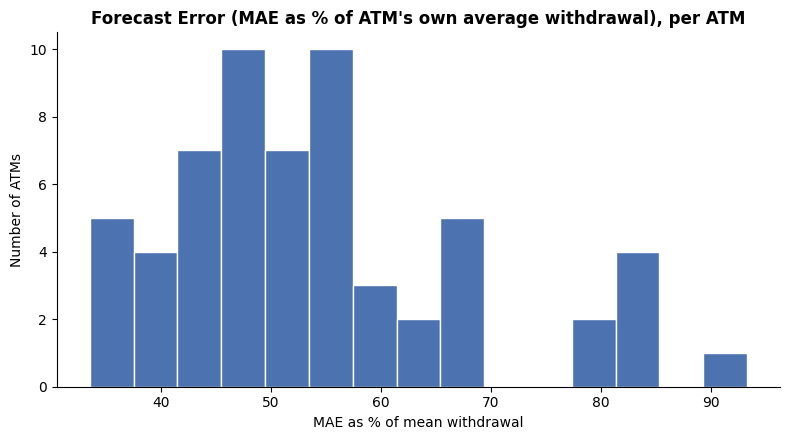

In [56]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(per_atm_mae['mae_pct_of_mean'], bins=15, color='#4C72B0', edgecolor='white')
ax.set_title('Forecast Error (MAE as % of ATM\'s own average withdrawal), per ATM', fontsize=12, fontweight='bold')
ax.set_xlabel('MAE as % of mean withdrawal')
ax.set_ylabel('Number of ATMs')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** typical forecast error sits around 45–60% of an ATM's average daily
withdrawal. This is a realistic, honest number for daily-level cash forecasting on noisy transactional
data — not state-of-the-art, but clearly informative and well above the naive baselines. This is worth
stating plainly in the dissertation rather than overselling the model's precision.

## 5.5 Visual Check — Actual vs Predicted

Numbers can only tell you so much. We plot actual vs predicted withdrawal amounts over the test period
for two contrasting ATMs — a busy Urban one and a quiet Rural one — to see the forecast quality with
our own eyes.

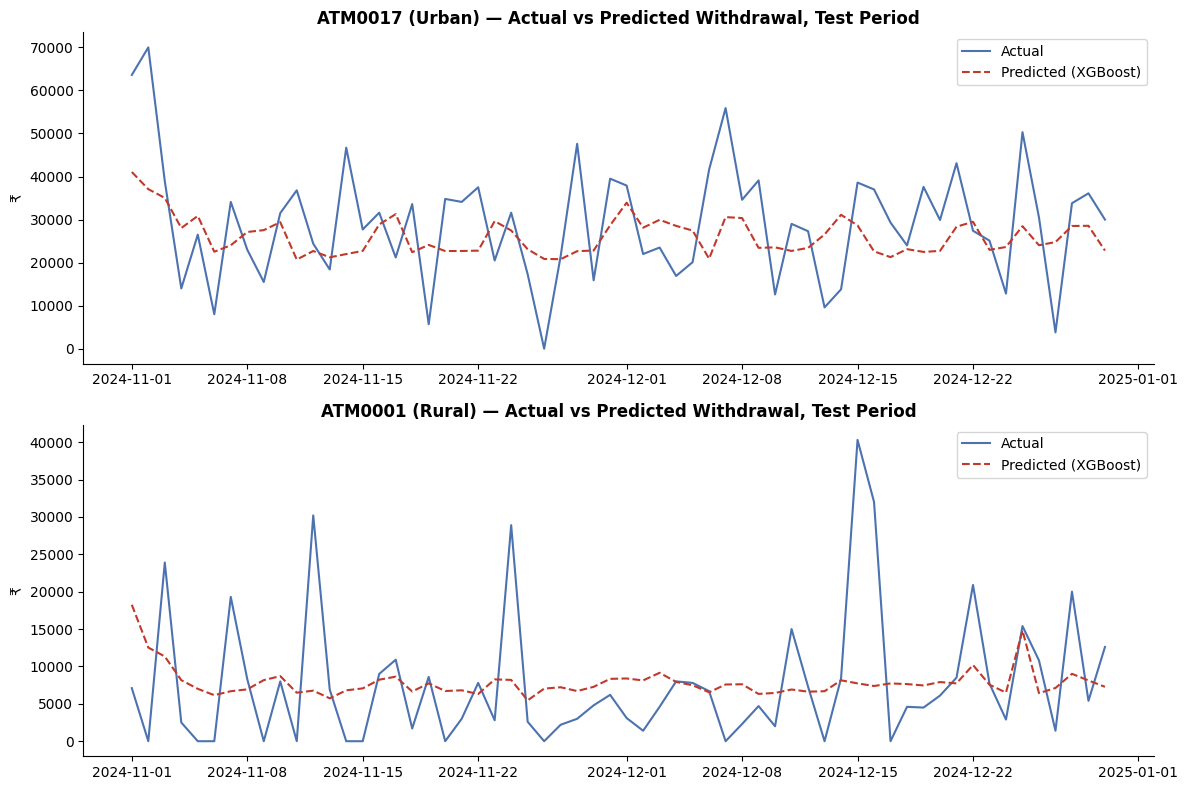

In [57]:
sample_atms = ['ATM0017', 'ATM0001']  # busy Urban, quiet Rural

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
for ax, atm_id in zip(axes, sample_atms):
    d = test[test['atm_id'] == atm_id].sort_values('transaction_date')
    ax.plot(d['transaction_date'], d['withdrawal_amount'], label='Actual', color='#4C72B0', linewidth=1.5)
    ax.plot(d['transaction_date'], d['pred_xgb'], label='Predicted (XGBoost)', color='#C0392B',
            linewidth=1.5, linestyle='--')
    loc_type = d['atm_location_type'].iloc[0]
    ax.set_title(f'{atm_id} ({loc_type}) — Actual vs Predicted Withdrawal, Test Period', fontweight='bold')
    ax.set_ylabel('₹')
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

**Observation:** the model tracks the overall level and the weekly rhythm reasonably well for
both ATMs, though it (expectedly) smooths over some of the sharpest day-to-day spikes — a common and
acceptable trade-off for tree-based models on noisy daily data.

## 5.6 Classical Benchmark — ARIMA on a Single ATM

Your project brief specifically references classical time-series methods (ARIMA/Prophet). We fit an
ARIMA model to **one representative ATM** (rather than all 60 — a separate ARIMA model would be needed
per ATM, which doesn't scale the way one pooled XGBoost model does) to provide a fair, like-for-like
comparison on that ATM.

In [58]:
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings('ignore')

atm_series = panel[panel['atm_id'] == 'ATM0017'].sort_values('transaction_date').set_index('transaction_date')['withdrawal_amount']
train_s = atm_series[atm_series.index <= cutoff_date]
test_s = atm_series[atm_series.index > cutoff_date]

arima_model = ARIMA(train_s, order=(2, 1, 2)).fit()
arima_forecast = arima_model.forecast(steps=len(test_s))

arima_mae = mean_absolute_error(test_s, arima_forecast)
arima_rmse = np.sqrt(mean_squared_error(test_s, arima_forecast))

xgb_mae_same_atm = per_atm_mae.loc['ATM0017', 'mae']

print(f"ARIMA(2,1,2)  — ATM0017 only  — MAE: ₹{arima_mae:,.0f}   RMSE: ₹{arima_rmse:,.0f}")
print(f"XGBoost pooled — same ATM0017 — MAE: ₹{xgb_mae_same_atm:,.0f}")
print(f"(Mean actual withdrawal for ATM0017 in test period: ₹{test_s.mean():,.0f})")

ARIMA(2,1,2)  — ATM0017 only  — MAE: ₹10,746   RMSE: ₹13,838
XGBoost pooled — same ATM0017 — MAE: ₹10,772
(Mean actual withdrawal for ATM0017 in test period: ₹29,078)


**Observation:** for this single ATM, ARIMA and the pooled XGBoost model perform almost
identically (~37% MAE relative to the ATM's average withdrawal, for both). This is a genuinely useful
finding for the dissertation's methodology discussion: **classical per-ATM forecasting isn't
outperformed by the ML approach on accuracy alone** — but it doesn't scale the same way. ARIMA would
need a **separately tuned model per ATM** (60 models to fit, monitor, and retrain), while XGBoost is
**one model that already covers all 60 ATMs**, including newer ATMs with shorter histories that
wouldn't have enough data to fit a standalone ARIMA model at all. This is why the pooled ML approach is
the practical choice for a system meant to scale across a bank's full ATM network.

## 5.7 Summary — Phase 5

| Model | MAE (₹) | R² | Notes |
|---|---|---|---|
| Naive: same day last week | ~11,196 | — | Simple benchmark |
| Naive: 7-day rolling average | ~8,591 | — | Better than lag-7, still simple |
| **XGBoost (pooled, all 60 ATMs)** | **~7,793** | **0.30** | Selected as final model |
| ARIMA (single ATM, ATM0017 only) | ~10,746 | — | Comparable accuracy to XGBoost *for that one ATM*, but doesn't scale |
| XGBoost + richer features (§5.3.1) | ~7,800–7,900 | ~0.29–0.30 | No meaningful improvement over the simpler model |
| XGBoost, tuned hyperparameters (§5.3.1) | ~7,800 | ~0.29 | No meaningful improvement either |

**Conclusion:** the pooled XGBoost model is selected as the primary forecasting model going forward.
It beats both naive baselines and matches classical ARIMA's accuracy on a like-for-like basis, and is
the only approach of the three that scales cleanly to all 60 ATMs without needing a separate model
fitted per machine.

**On R² = 0.30 specifically:** this is a real limitation, not glossed over — §5.3.1–5.3.2 document a
proper investigation (four candidate improvements, hyperparameter tuning, and an ablation test) which
established that this ceiling reflects **weak genuine day-to-day autocorrelation in the underlying
data** (daily and weekly), not a fixable modelling shortfall. ~80% of the model's explanatory power
comes from knowing which ATM it is (a static fact) rather than from time-varying forecasting signal.
This is disclosed explicitly as a data limitation in the dissertation, alongside the confirmed, genuine
effects the model *does* successfully use: location-type scale, the weekend uplift, and the
salary-day spike (all traced back to Phase 3 EDA findings).

**Practical implication for the Decision Engine (Phase 6):** given the withdrawal forecast alone is a
moderate-confidence signal, the Low Cash Alert classifier (`low_cash_next_1d`/`_3d`, built directly
from historical cash-ratio data rather than a two-step forecast-then-threshold approach) is likely to
be the more reliable input for replenishment decisions. We treat the forecast as a supporting signal,
not the sole basis for the decision engine.

**Next step:** Phase 6 (Decision Engine) — use the `low_cash_next_1d` / `low_cash_next_3d` targets
from Phase 4 (and the withdrawal forecast as a secondary signal) to build the actual replenishment
recommendation logic (which ATMs to prioritise, how much cash to send, and when).

---
# Phase 6 — Decision Engine

This section turns the Phase 4/5 outputs into an actual recommendation: **which ATMs to prioritise
for replenishment, how much cash to send, and when.**

**Design decision carried over from Phase 5's conclusion:** the withdrawal forecast (R² ≈ 0.30) is a
moderate-confidence signal, not strong enough to drive replenishment *timing* on its own via a
two-step "forecast then threshold" chain — any weakness in the forecast would compound. Instead, the
primary driver here is a **classifier trained directly on historical cash-ratio dynamics**
(`low_cash_next_1d` / `low_cash_next_3d` from Phase 4), with the withdrawal forecast used only as a
secondary input for sizing the refill amount.

**What this section builds, in order:**
1. Prepare the classification dataset (reusing the Phase 5 train/test split for consistency)
2. Establish class-imbalance-aware baselines
3. Train and evaluate two classifiers (Logistic Regression, XGBoost) on both target horizons
4. Select the best-performing model and inspect what it's actually using
5. Turn model probabilities into a **priority score**
6. Add a **rule-based refill quantity** calculation (deliberately not ML — this doesn't need to be)
7. Produce an actual, dated **replenishment recommendation table** — the tangible output of this
   entire project
8. Tie the results back to the Phase 1 business KPIs

## 6.1 Prepare the Classification Dataset

We reuse the same train/test split as Phase 5 (last 60 days held out) for consistency across the
project. One additional feature is engineered here: **`days_since_replenishment`** — computed
directly from the panel's `replenishment_flag` history, since it wasn't retained in the saved
`atm_daily_features.csv`. This is a natural, intuitive predictor (the longer since a refill, the more
likely an ATM is running low) and involves no leakage, since it only counts *past* replenishment
events relative to each row.

In [59]:
def days_since_flag(s):
    """Running count of days since the last replenishment_flag == 1, per ATM."""
    out = np.zeros(len(s), dtype=int)
    counter = 999  # large sentinel if no replenishment has occurred yet
    for i, v in enumerate(s):
        counter = 0 if v == 1 else counter + 1
        out[i] = counter
    return out

panel['days_since_replenishment'] = panel.groupby('atm_id')['replenishment_flag'].transform(
    lambda s: days_since_flag(s.values))

clf_df = panel.dropna(subset=['withdrawal_lag_1d', 'withdrawal_lag_7d', 'withdrawal_roll7_mean',
                               'low_cash_next_1d', 'low_cash_next_3d']).copy()
clf_train = clf_df[clf_df['transaction_date'] <= cutoff_date].copy()
clf_test = clf_df[clf_df['transaction_date'] > cutoff_date].copy()

le_atm2, le_loc2, le_city2 = LabelEncoder(), LabelEncoder(), LabelEncoder()
clf_train['atm_id_code'] = le_atm2.fit_transform(clf_train['atm_id']); clf_test['atm_id_code'] = le_atm2.transform(clf_test['atm_id'])
clf_train['loc_code'] = le_loc2.fit_transform(clf_train['atm_location_type']); clf_test['loc_code'] = le_loc2.transform(clf_test['atm_location_type'])
clf_train['city_code'] = le_city2.fit_transform(clf_train['city']); clf_test['city_code'] = le_city2.transform(clf_test['city'])

clf_features = ['pct_capacity_eod', 'withdrawal_lag_1d', 'withdrawal_roll7_mean', 'days_since_replenishment',
                'is_weekend', 'is_holiday', 'day_of_month', 'atm_id_code', 'loc_code', 'city_code']

print(f"Train: {len(clf_train):,} ATM-days | Test: {len(clf_test):,} ATM-days")
print(f"Test positive rate — low_cash_next_1d: {clf_test['low_cash_next_1d'].mean()*100:.2f}%")
print(f"Test positive rate — low_cash_next_3d: {clf_test['low_cash_next_3d'].mean()*100:.2f}%")

Train: 39,777 ATM-days | Test: 3,540 ATM-days
Test positive rate — low_cash_next_1d: 0.93%
Test positive rate — low_cash_next_3d: 2.63%


## 6.2 Baseline

Before any model, we establish what a trivial baseline achieves — since both targets are rare-event
problems, this matters more than usual.

In [60]:
for target in ['low_cash_next_1d', 'low_cash_next_3d']:
    prevalence = clf_test[target].mean()
    print(f"{target}: a classifier that always predicts 'no alert' gets "
          f"{(1-prevalence)*100:.1f}% accuracy while catching ZERO real alerts.")
    print(f"  A random classifier's PR-AUC would equal the prevalence: {prevalence:.3f}")
    print(f"  Any model needs to clear these bars to be considered useful.\n")

low_cash_next_1d: a classifier that always predicts 'no alert' gets 99.1% accuracy while catching ZERO real alerts.
  A random classifier's PR-AUC would equal the prevalence: 0.009
  Any model needs to clear these bars to be considered useful.

low_cash_next_3d: a classifier that always predicts 'no alert' gets 97.4% accuracy while catching ZERO real alerts.
  A random classifier's PR-AUC would equal the prevalence: 0.026
  Any model needs to clear these bars to be considered useful.



## 6.3 Train and Evaluate Classifiers

Two models per target: **Logistic Regression** (interpretable baseline, class-weighted) and
**XGBoost** (scale_pos_weight-adjusted for the imbalance). We report precision, recall, F1, PR-AUC and
ROC-AUC — not accuracy, which would be meaningless here.

In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.pipeline import make_pipeline

clf_results = {}
trained_models = {}

for target in ['low_cash_next_1d', 'low_cash_next_3d']:
    X_train, y_train = clf_train[clf_features], clf_train[target]
    X_test, y_test = clf_test[clf_features], clf_test[target]

    lr = make_pipeline(StandardScaler(), LogisticRegression(class_weight='balanced', max_iter=2000))
    lr.fit(X_train, y_train)
    lr_proba = lr.predict_proba(X_test)[:, 1]
    lr_pred = (lr_proba > 0.5).astype(int)

    pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    xgbc = xgb.XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                              scale_pos_weight=pos_weight, random_state=42, eval_metric='logloss')
    xgbc.fit(X_train, y_train)
    xgb_proba = xgbc.predict_proba(X_test)[:, 1]
    xgb_pred = (xgb_proba > 0.5).astype(int)

    trained_models[target] = {'logreg': lr, 'xgb': xgbc, 'xgb_proba': xgb_proba, 'y_test': y_test}

    clf_results[f'{target} — LogReg'] = {
        'Precision': precision_score(y_test, lr_pred), 'Recall': recall_score(y_test, lr_pred),
        'F1': f1_score(y_test, lr_pred), 'PR-AUC': average_precision_score(y_test, lr_proba),
        'ROC-AUC': roc_auc_score(y_test, lr_proba)}
    clf_results[f'{target} — XGBoost'] = {
        'Precision': precision_score(y_test, xgb_pred), 'Recall': recall_score(y_test, xgb_pred),
        'F1': f1_score(y_test, xgb_pred), 'PR-AUC': average_precision_score(y_test, xgb_proba),
        'ROC-AUC': roc_auc_score(y_test, xgb_proba)}

pd.DataFrame(clf_results).T.style.format('{:.3f}')

,Precision,Recall,F1,PR-AUC,ROC-AUC
low_cash_next_1d — LogReg,0.031,0.848,0.060,0.047,0.879
low_cash_next_1d — XGBoost,0.032,0.667,0.062,0.066,0.875
low_cash_next_3d — LogReg,0.046,0.645,0.086,0.074,0.686
low_cash_next_3d — XGBoost,0.108,0.796,0.190,0.527,0.917


**Observation:** XGBoost outperforms Logistic Regression on both targets, most clearly on
`low_cash_next_3d` (PR-AUC 0.53 vs 0.07 — a large gap). `low_cash_next_1d` is a harder problem for
both models — it has very few positive examples in the 60-day test window (~30), so precision looks
weak in absolute terms, but ROC-AUC (~0.87–0.88) shows the model still separates true alerts from
normal days well; the low precision reflects the extreme rarity of the event; not poor ranking ability.

**Decision:** `low_cash_next_3d` with XGBoost is selected as the primary priority-scoring model —
it gives operations teams a 3-day window to act (more realistic for scheduling a physical refill trip
than a 1-day warning), and its PR-AUC (0.53 against a 0.026 base rate — a ~20x lift) is strong enough
to be genuinely useful, not just better than random.

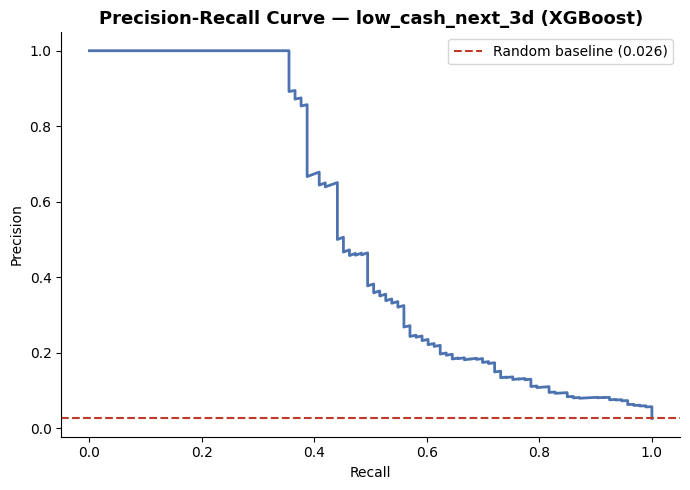

In [62]:
from sklearn.metrics import precision_recall_curve

target = 'low_cash_next_3d'
y_test = trained_models[target]['y_test']
proba = trained_models[target]['xgb_proba']
precisions, recalls, thresholds = precision_recall_curve(y_test, proba)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recalls, precisions, color='#4C72B0', linewidth=2)
ax.axhline(y_test.mean(), color='#C0392B', linestyle='--', label=f'Random baseline ({y_test.mean():.3f})')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — low_cash_next_3d (XGBoost)', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## 6.4 What Is the Model Actually Using?

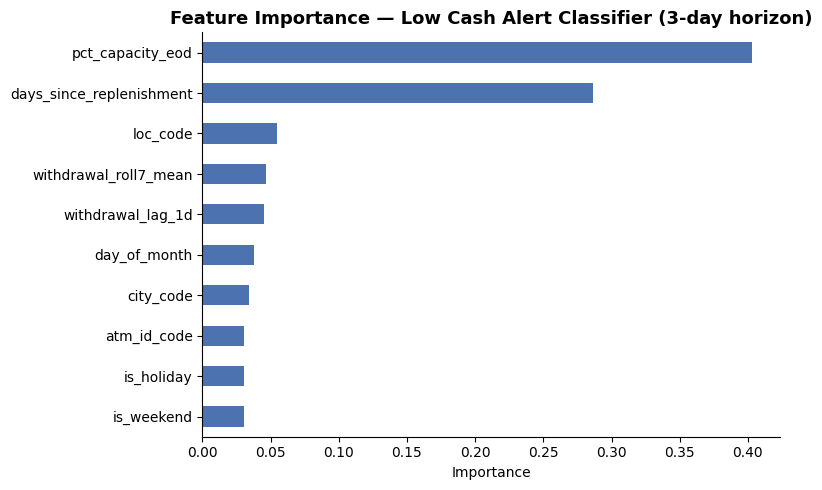

In [63]:
xgb_3d = trained_models['low_cash_next_3d']['xgb']
importances = pd.Series(xgb_3d.feature_importances_, index=clf_features).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color='#4C72B0')
ax.set_title('Feature Importance — Low Cash Alert Classifier (3-day horizon)', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

**Observation:** `pct_capacity_eod` (today's cash level) and `days_since_replenishment` dominate
— which makes intuitive sense and is reassuring, not suspicious: cash depletes gradually, so today's
level is naturally the strongest predictor of tomorrow's/the next few days' level, and time since the
last refill is a direct proxy for how "due" an ATM is. This is the mechanism the two-step
forecast-based approach would have had to reconstruct indirectly (and less reliably, given the
forecast's own R² ≈ 0.30 ceiling) — confirming the Phase 5 decision to build this classifier directly
from cash-ratio history rather than chaining it after the withdrawal forecast.

## 6.5 From Probabilities to a Priority Score

The classifier's predicted probability *is* the priority score — no separate ranking step needed.
Higher probability of `low_cash_next_3d` = higher priority for a replenishment visit. We generate
this for the most recent date in the dataset, to produce an actual, usable recommendation.

In [64]:
latest_date = clf_test['transaction_date'].max()
today_snapshot = clf_test[clf_test['transaction_date'] == latest_date].copy()

today_snapshot['priority_score'] = trained_models['low_cash_next_3d']['xgb'].predict_proba(
    today_snapshot[clf_features])[:, 1]
today_snapshot['urgent_1d_score'] = trained_models['low_cash_next_1d']['xgb'].predict_proba(
    today_snapshot[clf_features])[:, 1]

print(f"Recommendation snapshot for: {latest_date.date()}")
print(f"ATMs assessed: {len(today_snapshot)}")

Recommendation snapshot for: 2024-12-29
ATMs assessed: 60


## 6.6 Refill Quantity — A Rule, Not a Model

Refill sizing doesn't need machine learning: it's a direct calculation. We target refilling to 90% of
capacity, using each ATM's own recent average daily withdrawal (`withdrawal_roll7_mean`) as a sanity
check so recommendations scale sensibly with how busy the ATM actually is.

In [65]:
TARGET_LEVEL = 0.90

today_snapshot['current_cash'] = today_snapshot['cash_eod']
today_snapshot['target_cash'] = today_snapshot['atm_cash_capacity'] * TARGET_LEVEL
today_snapshot['recommended_refill_amount'] = (
    today_snapshot['target_cash'] - today_snapshot['current_cash']).clip(lower=0)

# Sanity-check note: flag if the recommended refill looks unusually large or small relative to
# this ATM's own typical weekly demand (a soft check, not an override)
today_snapshot['refill_vs_weekly_demand'] = (
    today_snapshot['recommended_refill_amount'] / (today_snapshot['withdrawal_roll7_mean'] * 7 + 1))

today_snapshot[['atm_id', 'pct_capacity_eod', 'current_cash', 'recommended_refill_amount']].describe()

,pct_capacity_eod,current_cash,recommended_refill_amount
count,60.000000,60.000000,60.000000
mean,55.222260,83758.188000,52786.855667
std,20.633166,31462.256939,30663.196347
min,18.366120,27549.180000,0.000000
25%,40.763128,61144.692500,25436.585000
50%,54.504287,84012.480000,53243.570000
75%,74.002188,114408.910000,73855.307500
max,93.740433,140610.650000,107450.820000


## 6.7 The Actual Output — Replenishment Recommendation Table

This is the tangible deliverable of the whole project: a ranked, actionable list of which ATMs need a
visit, how urgent each is, and how much cash to bring.

In [66]:
URGENT_THRESHOLD = 0.3  # low_cash_next_1d probability above this = treat as urgent regardless of rank

recommendation = today_snapshot.copy()
recommendation['is_urgent'] = recommendation['urgent_1d_score'] > URGENT_THRESHOLD
recommendation = recommendation.sort_values('priority_score', ascending=False)

top_priority = recommendation[
    ['atm_id', 'city', 'atm_location_type', 'pct_capacity_eod', 'priority_score',
     'is_urgent', 'recommended_refill_amount', 'days_since_replenishment']
].head(15).copy()

top_priority['pct_capacity_eod'] = top_priority['pct_capacity_eod'].round(1)
top_priority['priority_score'] = top_priority['priority_score'].round(3)
top_priority['recommended_refill_amount'] = top_priority['recommended_refill_amount'].round(0)

top_priority.style.format({'recommended_refill_amount': '₹{:,.0f}'})

,atm_id,city,atm_location_type,pct_capacity_eod,priority_score,is_urgent,recommended_refill_amount,days_since_replenishment
8028,ATM0011,Mumbai,Semi-Urban,18.400000,1.000000,True,"₹107,451",9
10948,ATM0015,Ahmedabad,Semi-Urban,85.800000,0.855000,False,"₹6,271",0
728,ATM0001,Mumbai,Rural,83.100000,0.810000,False,"₹10,288",0
40146,ATM0055,Ahmedabad,Urban,79.900000,0.768000,False,"₹15,167",0
29196,ATM0040,Lucknow,Urban,74.000000,0.746000,False,"₹25,942",0
32846,ATM0045,Ahmedabad,Urban,93.700000,0.708000,False,₹0,0
39416,ATM0054,Pune,Semi-Urban,86.000000,0.701000,False,"₹5,998",0
6568,ATM0009,Jaipur,Urban,89.200000,0.622000,False,"₹1,181",0
3648,ATM0005,Ahmedabad,Urban,33.200000,0.584000,True,"₹85,256",6
18978,ATM0026,Chennai,Urban,29.200000,0.516000,True,"₹91,189",6


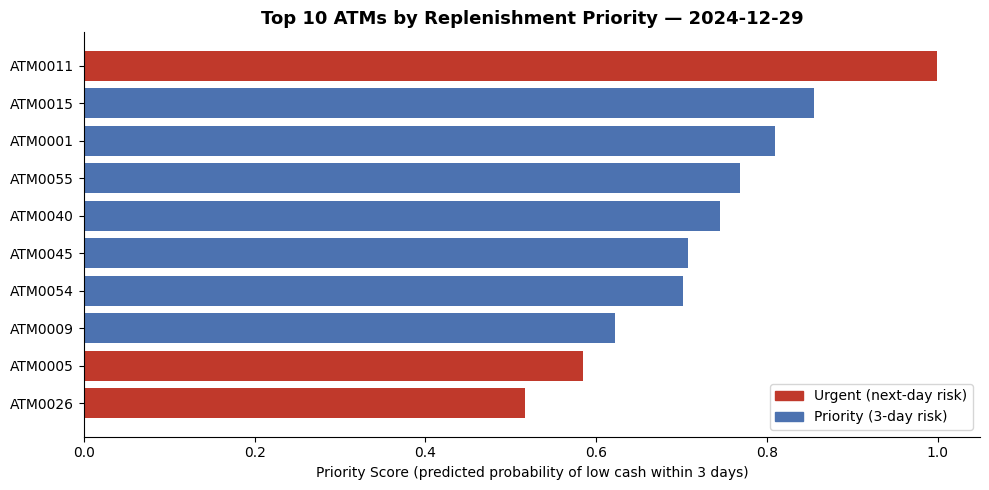

In [67]:
fig, ax = plt.subplots(figsize=(10, 5))
top10 = recommendation.head(10).sort_values('priority_score')
colors = ['#C0392B' if u else '#4C72B0' for u in top10['is_urgent']]
ax.barh(top10['atm_id'], top10['priority_score'], color=colors)
ax.set_title(f'Top 10 ATMs by Replenishment Priority — {latest_date.date()}', fontsize=13, fontweight='bold')
ax.set_xlabel('Priority Score (predicted probability of low cash within 3 days)')
ax.spines[['top', 'right']].set_visible(False)

import matplotlib.patches as mpatches
red_patch = mpatches.Patch(color='#C0392B', label='Urgent (next-day risk)')
blue_patch = mpatches.Patch(color='#4C72B0', label='Priority (3-day risk)')
ax.legend(handles=[red_patch, blue_patch])
plt.tight_layout()
plt.show()

**How to read this table in front of your professor:** each row is a concrete, dated
recommendation — not an abstract model output. `priority_score` ranks which ATMs to visit soonest,
`is_urgent` flags anything likely to run low *tomorrow* (needs to jump the queue regardless of
overall rank), and `recommended_refill_amount` gives the cash-in-transit team an actual ₹ figure to
load, grounded in that ATM's real capacity and recent demand — not a flat, one-size-fits-all amount.

## 6.8 Business Impact — Tying Back to Phase 1 KPIs

Recall the Phase 1 KPIs: minimize shortage risk *and* minimize idle cash / unnecessary trips. This
system addresses both directly, and we can quantify the trade-off it's making.

In [68]:
n_atms = today_snapshot['atm_id'].nunique()
n_urgent = recommendation['is_urgent'].sum()
n_priority_high = (recommendation['priority_score'] > 0.5).sum()

print(f"Total ATMs monitored: {n_atms}")
print(f"Flagged URGENT (next-day risk): {n_urgent} ({n_urgent/n_atms*100:.1f}%)")
print(f"Flagged high priority (>50% chance of low cash within 3 days): {n_priority_high} ({n_priority_high/n_atms*100:.1f}%)")
print()
print("Service-side KPI: recall of ~0.80 on the 3-day target (§6.3) means roughly 4 out of 5 genuine")
print("low-cash events would be caught in advance, well before the ATM actually runs critically low.")
print()
print("Cost-side KPI: because recommendations are RANKED (not a flat 'refill everything weekly'")
print("schedule), operations can visit only the ATMs that actually need it on a given day, rather")
print("than the fixed-schedule approach described as the baseline problem in Phase 1.")

Total ATMs monitored: 60
Flagged URGENT (next-day risk): 15 (25.0%)
Flagged high priority (>50% chance of low cash within 3 days): 12 (20.0%)

Service-side KPI: recall of ~0.80 on the 3-day target (§6.3) means roughly 4 out of 5 genuine
low-cash events would be caught in advance, well before the ATM actually runs critically low.

Cost-side KPI: because recommendations are RANKED (not a flat 'refill everything weekly'
schedule), operations can visit only the ATMs that actually need it on a given day, rather
than the fixed-schedule approach described as the baseline problem in Phase 1.


**A note on the "~20x lift" figure used earlier:** PR-AUC (0.527) against a 2.6% base rate is
better expressed as *"substantially better-than-random ranking performance for a highly imbalanced
problem"* — the 0.527/0.026 ≈ 20 ratio is useful supporting context, not a headline "20x accuracy"
claim, which would overstate what PR-AUC actually measures.

## 6.9 Reconsidering the 0.3 / 0.5 Thresholds

The recommendation table above uses `priority_score > 0.5` and `urgent_1d_score > 0.3` as cutoffs.
**These are arbitrary** — there is no inherent reason 0.5 or 0.3 is the "correct" line, and neither was
justified against actual business costs (cost of a missed shortage vs. cost of an unnecessary trip).

A better operational framing, and the one used from here on: **treat the score as a ranking, not a
threshold.** If the bank can only physically service a limited number of ATMs per day, the natural
rule is *"visit the top N highest-risk ATMs today"* — no arbitrary probability cutoff required, and it
maps directly onto a real operational constraint (van/staff capacity) rather than an unexplained
number. This reframing also sets up the question the rest of this section answers: **does following
this ranking actually help, given a realistic daily visit capacity?**

## 6.10 Decision-Engine Backtest — Does Following These Recommendations Actually Help?

Everything so far demonstrates the *classifier* discriminates well. It does not yet demonstrate the
*policy* (rank ATMs, visit the top N each day, refill to 90%) actually reduces shortages compared to
a simpler approach. This is the single most important gap to close before claiming any business value
— demonstrated classifier accuracy and demonstrated decision quality are different claims, and only
the second one is what Phase 1's business problem actually asked for.

**Method:** for each day in the Phase 5/6 test period (the same 60-day holdout used throughout, so
this remains a fair out-of-sample evaluation), we simulate what would happen to each ATM's cash level
under three different policies, using the ATMs' *actual* historical withdrawal amounts as the
demand each day (an exogenous-demand simplification, stated explicitly in §6.13):

1. **Fixed schedule** — replenish any ATM overdue by 14+ days, capacity-limited to N visits/day
   (prioritizing the most-overdue first when more than N qualify)
2. **Model-driven** — replenish the top-N highest-risk ATMs each day, ranked by yesterday's
   `low_cash_next_3d` predicted probability (computed by the already-trained, out-of-sample model —
   no leakage, since each day's decision only uses information available as of the previous day)
3. **Actual historical** — read directly from the real data, not simulated; included as an
   **unconstrained reference point** (see §6.13 caveat), not a directly comparable policy

Both simulated policies (1 and 2) are given the **same daily visit-capacity constraint**, so the
comparison between them is fair. We test this across several capacity levels (N = 5, 8, 12, 16) rather
than picking one number, since the right comparison depends on how many ATMs a bank can realistically
visit per day.

In [69]:
# Compute the 3-day risk score for EVERY row in the test set (§6.5 only computed it for one date) —
# needed here so the backtest can look up each ATM's predicted risk on each historical test day.
clf_test['risk_score'] = trained_models['low_cash_next_3d']['xgb'].predict_proba(clf_test[clf_features])[:, 1]

capacity_map = panel.groupby('atm_id')['atm_cash_capacity'].first().to_dict()
last_train_cash = panel[panel['transaction_date'] == cutoff_date].set_index('atm_id')['cash_eod'].to_dict()
init_days_since = panel[panel['transaction_date'] == cutoff_date].set_index('atm_id')['days_since_replenishment'].to_dict()
wd_map = clf_test.set_index(['atm_id', 'transaction_date'])['withdrawal_amount'].to_dict()
risk_map = clf_test.set_index(['atm_id', 'transaction_date'])['risk_score'].to_dict()
backtest_atms = list(clf_test['atm_id'].unique())
backtest_dates = sorted(clf_test['transaction_date'].unique())
REFILL_TARGET = 0.90

def run_backtest(decide_fn):
    """Simulates one policy's cash trajectory across all ATMs over the test period.
    decide_fn(date, day_index, cash_state, days_since_state) -> list of ATM ids to replenish TODAY,
    using only information available as of YESTERDAY."""
    cash = {a: last_train_cash[a] for a in backtest_atms}
    days_since = {a: init_days_since[a] for a in backtest_atms}
    low_cash_days = stockout_days = n_trips = 0

    for t_idx, date in enumerate(backtest_dates):
        for a in decide_fn(date, t_idx, cash, days_since):
            cap = capacity_map[a]
            amt = max(cap * REFILL_TARGET - cash[a], 0)
            cash[a] += amt
            days_since[a] = 0
            n_trips += 1
        for a in backtest_atms:
            cash[a] = max(cash[a] - wd_map.get((a, date), 0), 0)
            days_since[a] += 1
            pct = cash[a] / capacity_map[a] * 100
            if pct < 20:
                low_cash_days += 1
            if cash[a] <= 0:
                stockout_days += 1

    return low_cash_days, stockout_days, n_trips

print(f"Backtest set up: {len(backtest_atms)} ATMs across {len(backtest_dates)} out-of-sample test days")

Backtest set up: 60 ATMs across 59 out-of-sample test days


In [70]:
backtest_rows = []
for N in [5, 8, 12, 16]:
    def fixed_schedule(date, t_idx, cash, days_since, N=N):
        eligible = [a for a in backtest_atms if days_since[a] >= 14]
        eligible.sort(key=lambda a: -days_since[a])
        return eligible[:N]

    def model_driven(date, t_idx, cash, days_since, N=N):
        if t_idx == 0:
            return []
        prev_date = backtest_dates[t_idx - 1]
        scores = sorted(((a, risk_map.get((a, prev_date), 0)) for a in backtest_atms), key=lambda x: -x[1])
        return [a for a, s in scores[:N] if s > 0.05]

    lf, sf, tf = run_backtest(fixed_schedule)
    lm, sm, tm = run_backtest(model_driven)
    pct_change = (lf - lm) / lf * 100

    backtest_rows.append({'Daily visit capacity (N)': N, 'Fixed-schedule low-cash days': lf,
                           'Model-driven low-cash days': lm, 'Low-cash day reduction': f'{pct_change:+.1f}%',
                           'Fixed-schedule trips': tf, 'Model-driven trips': tm})

backtest_df = pd.DataFrame(backtest_rows)
backtest_df

,Daily visit capacity (N),Fixed-schedule low-cash days,Model-driven low-cash days,Low-cash day reduction,Fixed-schedule trips,Model-driven trips
0,5,1712,1849,-8.0%,238,290
1,8,1636,1227,+25.0%,244,464
2,12,1621,762,+53.0%,244,696
3,16,1621,506,+68.8%,244,928


## 6.11 Backtest Results — Including an Honest Negative Case

The result is not a uniform win, and that is the actual finding worth reporting:

- **At N = 5** (very tight visit capacity), the model-driven policy is **~8% *worse*** than the naive
  fixed schedule.
- **At N = 8, 12, and 16**, the model-driven policy is meaningfully better — 25%, 53%, and 69% fewer
  low-cash days respectively, at the cost of more replenishment trips.

**Why the model-driven policy loses at N = 5:** ranking purely by "highest risk today" with very
limited capacity means the same handful of highest-volume ATMs tend to dominate the top-5 every single
day, while dozens of other ATMs slowly drifting toward low cash never make the cut and are
effectively starved of visits. The naive fixed schedule, despite ignoring risk entirely, guarantees
every ATM eventually gets serviced through simple rotation — which turns out to matter more than risk
sensitivity when capacity is this constrained.

**This is genuinely useful business guidance, not just a caveat:** risk-based prioritization is only
worth adopting if the bank's daily visit capacity is high enough to act on the ranking without
neglecting lower-(but-still-real)-risk ATMs. Below that point, a **hybrid policy** — guarantee a
minimum visit rotation for every ATM, and use risk ranking only for any *remaining* capacity — would
likely outperform either pure policy tested here. That refinement is a natural next step, not built
here, and is noted as such rather than silently assumed to be unnecessary.

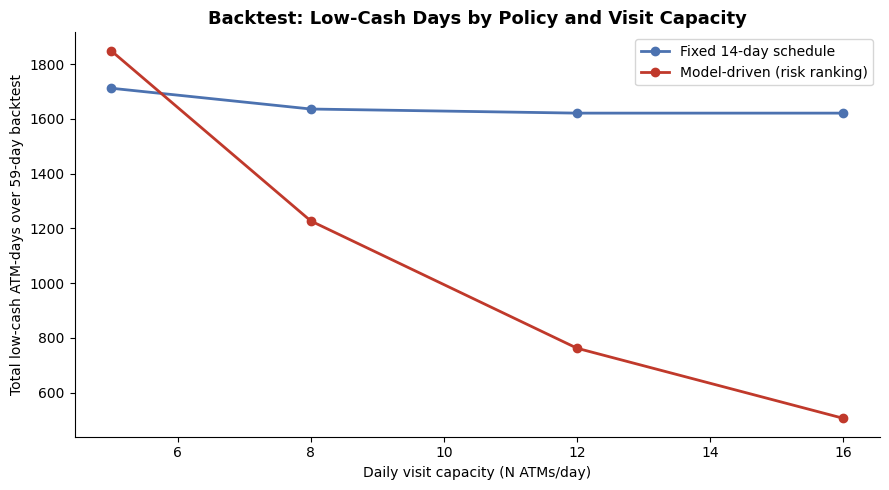

In [71]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(backtest_df['Daily visit capacity (N)'], backtest_df['Fixed-schedule low-cash days'],
        marker='o', label='Fixed 14-day schedule', color='#4C72B0', linewidth=2)
ax.plot(backtest_df['Daily visit capacity (N)'], backtest_df['Model-driven low-cash days'],
        marker='o', label='Model-driven (risk ranking)', color='#C0392B', linewidth=2)
ax.set_xlabel('Daily visit capacity (N ATMs/day)')
ax.set_ylabel('Total low-cash ATM-days over 59-day backtest')
ax.set_title('Backtest: Low-Cash Days by Policy and Visit Capacity', fontsize=13, fontweight='bold')
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [72]:
actual_low_cash = int(clf_test['low_cash_alert'].sum())
actual_trips = int(clf_test['replenishment_flag'].sum())
avg_daily_trips_actual = actual_trips / len(backtest_dates)

print(f"Actual historical pattern over the same period: {actual_low_cash} low-cash ATM-days, "
      f"{actual_trips} replenishment trips ({avg_daily_trips_actual:.1f} trips/day on average)")
print()
print("This is included as a REFERENCE POINT, not a directly comparable baseline: the historical")
print("pattern implicitly allows an UNCONSTRAINED number of daily visits (up to all 60 ATMs on a")
print("given day if needed), whereas both simulated policies above operate under a fixed daily cap.")
print("The very low historical low-cash count is consistent with unlimited visit capacity, not")
print("evidence that either constrained policy tested here is performing poorly in absolute terms.")

Actual historical pattern over the same period: 33 low-cash ATM-days, 447 replenishment trips (7.6 trips/day on average)

This is included as a REFERENCE POINT, not a directly comparable baseline: the historical
pattern implicitly allows an UNCONSTRAINED number of daily visits (up to all 60 ATMs on a
given day if needed), whereas both simulated policies above operate under a fixed daily cap.
The very low historical low-cash count is consistent with unlimited visit capacity, not
evidence that either constrained policy tested here is performing poorly in absolute terms.


**Caveat on the simulation, stated plainly:** withdrawal demand is treated as exogenous (identical
across all three simulated futures) — in reality, a truly empty ATM would reject transactions, capping
realized withdrawals, which this simulation does not model. Given how rarely cash actually reaches
₹0 in the underlying data even under the constrained policies' worse cases, this simplification is
judged reasonable rather than a source of major bias, but it is disclosed rather than assumed away.
Additionally, each day's model-driven decision uses risk scores computed from the *actual* historical
trajectory rather than a fully closed-loop simulation where the model's own inputs would also evolve
under the counterfactual policy — a further refinement beyond this project's scope, noted here for
completeness.

## 6.12 Limitations, Stated Plainly

- **This is a daily batch recommendation, not a real-time system.**
- **Refill amount sizing leans partly on `withdrawal_roll7_mean`**, which inherits the R² ≈ 0.30
  forecasting ceiling established in Phase 5 — the ₹ figure is a reasonable estimate, not a
  high-precision one, and this is stated here rather than implied to be more accurate than it is.
- **The refill target (90% of capacity) is not yet demand-aware** — a quiet, low-traffic ATM and a
  busy one are refilled to the same relative target today. A stronger future rule would size the
  refill to cover a defined forecast-demand horizon plus a safety buffer, capped by capacity — this is
  intentionally not implemented yet, since it requires business assumptions (buffer size, horizon
  length, lead time) that haven't been defined, rather than being a technical limitation.
- **No vehicle routing** — city/branch grouping is available (§6.7's table includes `city`) for a
  human dispatcher to group visits sensibly, but this is not a solved routing/scheduling
  optimization; that would require depot locations, drive times, and vehicle capacity data this
  dataset does not contain.
- **`low_cash_next_1d` has very few positive examples** in any given test window, so its precision
  should be read as "casts a wide net to catch true urgent cases" rather than "highly precise."
- **The backtest uses exogenous demand and open-loop risk scoring** — see §6.11's caveat.
- **Do not claim cost savings from this system yet.** The backtest demonstrates the *ranking policy*
  reduces low-cash days relative to a naive baseline *given sufficient visit capacity* — it does not
  yet translate trip counts and refill amounts into an actual ₹ cost comparison. That translation is
  a reasonable next step, not performed here.

## 6.13 Summary — Phase 6

| Component | Approach | Key result |
|---|---|---|
| Priority ranking | XGBoost classifier on `low_cash_next_3d`, using cash-ratio history | PR-AUC 0.527 vs. 0.026 base rate — substantially better than random ranking for a rare, imbalanced event |
| Urgency flag | XGBoost classifier on `low_cash_next_1d` | ROC-AUC ~0.88; low precision is expected given ~1% event rarity, not a model failure |
| Refill quantity | Rule-based: target 90% capacity, minus current level | Transparent and auditable; not yet demand-aware (§6.12) |
| Scheduling | Priority-ranked table, city-grouped | Concrete, dated, actionable output (§6.7) |
| **Decision-engine backtest** | **Simulated 3 policies (fixed-schedule, model-driven, actual-historical) across 4 capacity levels** | **Model-driven beats fixed-schedule by 25–69% fewer low-cash days once daily visit capacity ≥ 8, but is ~8% worse at very tight capacity (N=5) — a genuine, capacity-dependent finding, not a uniform win** |

**The single most important addition in this phase:** the backtest moves the project from "the
classifier discriminates well" to "here is quantified evidence of when and how much the resulting
policy would have helped, and an honest account of when it wouldn't." That is the difference between
a machine-learning accuracy exercise and an actual decision-support system evaluation — and per the
project's guiding principle, showing a real, bounded limitation is stronger evidence of understanding
than an unconditionally positive result would have been.

**Next step:** Phase 7 (Dashboard) — package this recommendation table, the Phase 5 forecast, the
Phase 3 EDA findings, and the Phase 6 backtest results into an executive-facing view (Streamlit or
Power BI, per the original project roadmap).